# Прогностическая модель осложнений беременности и родов

## Краткое описание
Разработать модель машинного обучения, которая накапливает данные из карты пациентки на протяжении всей беременности — от постановки на учёт до родов — и на каждом этапе обновляет прогноз вероятности шести типов осложнений. Входные данные включают исходный анамнез, результаты первого и второго скрининга, лабораторные анализы, данные о течении беременности и результаты дополнительных обследований.

## Цель проекта
Создать динамический сервис предупреждения для врача: при каждом визите пациентки или внесении новых данных система автоматически пересчитывает риски и отображает их в виде числа (0–100%) или цветового индикатора (зелёный / жёлтый / красный) отдельно по каждому типу осложнения.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install catboost autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 5.1 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
INFO: pi

In [3]:
import os
import re
import json
from pathlib import Path
from typing import Any, Iterable, Literal
from dataclasses import dataclass, asdict
from datetime import datetime
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn as sk
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    jaccard_score,
    multilabel_confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost
from xgboost import XGBClassifier
import shap
import joblib
import autogluon
from autogluon.tabular import TabularPredictor

print(sk.__version__)
print(xgboost.__version__)
print(pd.__version__)

1.6.1
3.1.3
2.2.2


# Конфигурация

### Пути

In [4]:
BASE_DIR = Path('drive/MyDrive/colab/internship')
RAW_PATH = BASE_DIR / 'raw.xlsx'

OUT_DIR = BASE_DIR / 'processed'
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
REPORTS_DIR = BASE_DIR / 'reports'
FIGURES_DIR = BASE_DIR / 'figures'
EXPERIMENTS_DIR = REPORTS_DIR / "experiments"
EXPERIMENT_FIGURES_DIR = FIGURES_DIR / "experiments"

for dir in [OUT_DIR, ARTIFACTS_DIR, REPORTS_DIR, FIGURES_DIR, EXPERIMENTS_DIR, EXPERIMENT_FIGURES_DIR]:
    dir.mkdir(parents=True, exist_ok=True)

CLEAN_DATA_PATH = OUT_DIR / 'pregnancy_clean_labeled.csv'
COLUMN_MAP_PATH = OUT_DIR / 'column_mapping.json'
QUALITY_REPORT_PATH = OUT_DIR / 'quality_report.csv'
EARLY_FEATURE_REPORT_PATH = OUT_DIR / "early_feature_report.csv"
LATE_FEATURE_REPORT_PATH = OUT_DIR / "late_feature_report.csv"
FIRST_SCREENING_REPORT_PATH = OUT_DIR / "first_screening_completeness_report.csv"

X_EARLY_PATH = OUT_DIR / 'X_early_w14.csv'
X_LATE_PATH = OUT_DIR / 'X_late_w34.csv'
Y_PATH = OUT_DIR / 'y_labels.csv'
SCREENING_OCR_X_PATH = OUT_DIR / "X_screening_ocr_w14.csv"
SCREENING_OCR_FEATURE_REPORT_PATH = OUT_DIR / "screening_ocr_feature_report.csv"
SCREENING_OCR_MODEL_PATH = ARTIFACTS_DIR / "screening_ocr.joblib"


LABEL_COLUMNS = [
    'label_fgr',            # задержка роста плода
    'label_preterm',        # преждевременные роды
    'label_fetal_distress', # дистресс (недостаток кислорода)
    'label_preeclampsia',   # Преэклампсия
    'label_large_for_ga',   # слишком большая масса плода
    'label_normal',         # отсутствие патологий
]

COMPLICATION_LABELS = [
    'label_fgr',            # задержка роста плода
    'label_preterm',        # преждевременные роды
    'label_fetal_distress', # дистресс (недостаток кислорода)
    'label_preeclampsia',   # Преэклампсия
    'label_large_for_ga',   # слишком большая масса плода
]

LABEL_COLUMNS = COMPLICATION_LABELS + ['label_normal']



### Колонки

In [5]:
COMPLICATION_LABELS = [
    'label_fgr',            # задержка роста плода
    'label_preterm',        # преждевременные роды
    'label_fetal_distress', # дистресс (недостаток кислорода)
    'label_preeclampsia',   # Преэклампсия
    'label_large_for_ga',   # слишком большая масса плода
]

LABEL_COLUMNS = COMPLICATION_LABELS + ['label_normal']

ID_COLUMNS = [
    "patient_id",
    "pid",
    "his_number",
    "his_number_alt",
    "medical_card_number",
    "medical_card_number_dup",
    "full_name",
    "sex",
    "ethnicity"
]

# Технические колонки, которые обычно не нужны модели.
TECHNICAL_COLUMNS = [
    "operator",
    "fmf_operator",
    "fmf_code",
    "methodology",
    "risk_version",
    "reagents",
    "blood_sample_analysed",
]

# Эти поля известны после родов или напрямую содержат исход.
# Их можно использовать для разметки, но нельзя использовать как признаки ранней модели.
HARD_LEAKAGE_COLUMNS = [
    # Даты и срок родов
    "discharge_summary_date",
    "delivery_date",
    "delivery_date_dup",
    "gestational_age_delivery_raw",
    "gestational_age_delivery_raw_dup",
    "gestational_age_delivery_weeks",
    "gestational_age_delivery_weeks_dup",

    # Протокол родов
    "delivery_term_type",
    "delivery_onset",
    "delivery_type",
    "delivery_operation",
    "delivery_operation_indications",

    # Данные ребёнка после рождения
    "birth_weight",
    "birth_weight_dup",
    "birth_length",
    "head_circumference",
    "apgar_1",
    "apgar_5",

    # Исходы и диагнозы
    "fetus_outcome_1",
    "fetus_outcome_2",
    "fetus_outcome_3",
    "fetus_outcome_4",
    "fetus_outcome_5",
    "child_discharge_diagnosis",
    "delivery_diagnosis_text",

    # Очень близко к родам / операциям
    "preoperative_diagnosis_text",
    "pre_delivery_diary_diagnosis_text",
]

ANAMNESIS_RAW_TEXT_COLUMNS = [
    "past_diseases_text",
    "past_surgeries_text",
    "menstrual_function_text",
    "gynecological_diseases_text",
    "contraception_text",
    "ivf_method_text",
]


PREGNANCY_COURSE_TEXT_COLUMNS = [
    "pregnancy_course_text",
    "astraya_data_text",
]


POTENTIALLY_LATE_US_TEXT_COLUMNS = [
    "pre_delivery_us_conclusion_text",
]

# Общая обработка данных

## Загрузка

In [ ]:
def read_dataset(path: str | Path) -> pd.DataFrame:
    path = Path(path)

    if path.suffix.lower() in ['.xlsx', '.xls']:
        return pd.read_excel(path)

    if path.suffix.lower() == '.csv':
        return pd.read_csv(
            path,
            sep=';',
            encoding='utf-8-sig',
        )
    return ValueError(f'Unsupported file format: {path.suffix}')

## Переименование колонок

In [7]:
#@title Словарь с полями
COLUMN_RENAME = {
    # ID / технические поля
    "PATIENTS_ID": "patient_id",
    "PID": "pid",
    "HIS_number": "his_number",
    "HIS_number_": "his_number_alt",
    "NOMER_MEDICISKOJ_KART": "medical_card_number",
    "NOMER_MEDICISKOJ_KART.1": "medical_card_number_dup",
    "FULL_NAME": "full_name",

    # даты
    "Дата_ВыпЭпикриза": "discharge_summary_date",
    "Дата_Родов": "delivery_date",
    "Дата_Родов.1": "delivery_date_dup",
    "Дата_УЗИ11_13": "us_11_13_date",
    "Дата_УЗИ11_13.1": "us_11_13_date_dup",
    "ДатаПоследнейМенструации": "last_menstruation_date",
    "US_Date": "us_date",
    "Blood_sampling_date": "blood_sampling_date",

    # исходы / роды / ребенок
    "СрокГестации": "gestational_age_delivery_raw",
    "СрокГестации.1": "gestational_age_delivery_raw_dup",
    "СрокРодов_ПротРодов": "delivery_term_type",
    "Дата_Родов": "delivery_date",
    "ВесПлода": "birth_weight",
    "ВесПлода.1": "birth_weight_dup",
    "РостПлода": "birth_length",
    "Апгар_1": "apgar_1",
    "Апгар_5": "apgar_5",
    "ОкружностьГоловы": "head_circumference",
    "Исход1Плода": "fetus_outcome_1",
    "Исход2Плода": "fetus_outcome_2",
    "Исход3Плода": "fetus_outcome_3",
    "Исход4Плода": "fetus_outcome_4",
    "Исход5Плода": "fetus_outcome_5",
    "Диагноз_ребенкаВыписной": "child_discharge_diagnosis",
    "Диагнозы_ВыпЭпикриза_И_ПротоколаРодов": "delivery_diagnosis_text",
    "КолВоПлодов_ПротРодов": "fetuses_count_delivery_protocol",
    "НачалоРодов_ПротРодов": "delivery_onset",
    "ВидРодов_ПротРодов": "delivery_type",
    "Операция_ПротРодов": "delivery_operation",
    "Показания_В_Операции_Перед_Родами": "delivery_operation_indications",

    # демография / антропометрия
    "Пол": "sex",
    "Возраст_на_Дату_УЗИ_11_13": "age_at_us_11_13",
    "Age": "age",
    "РостНаНачалоБерем": "height_start_pregnancy",
    "ВесНаНачалоБерем": "weight_start_pregnancy",
    "ИМТНаНачалоБерем": "bmi_start_pregnancy",
    "НачальныйВес": "initial_weight",
    "Weight": "weight_prisca",
    "Height": "height_prisca",
    "Ethnic": "ethnicity",

    # анамнез
    "ПеренесенныеЗаболевания": "past_diseases_text",
    "ПеренесенныеОперации": "past_surgeries_text",
    "МенструальнаяФункция": "menstrual_function_text",
    "ГинекологическиеЗаболевания": "gynecological_diseases_text",
    "Контрацепция": "contraception_text",
    "ПерваяБеременость": "first_pregnancy_raw",
    "ПрименениеВРТ_ЭКО_вТекущейБеременности": "ivf_current_pregnancy_raw",
    "ЭКО_МетодЛЕчения": "ivf_method_text",
    "ДонорскиеОоциты": "donor_oocytes_raw",
    "ДонорскаяСперма": "donor_sperm_raw",
    "ПослеЭКО_изИтоговойЗаписиСтатистики": "after_ivf_stat_raw",
    "НомерДаннойБеременности": "pregnancy_number_raw",
    "ПерерывМеждуРодами": "interbirth_interval_raw",
    "ПредстоятРоды": "upcoming_delivery_raw",
    "КакойПоСчету": "child_order_raw",

    # течение беременности / тексты
    "ТечениеОсложнениеДаннойБеременности": "pregnancy_course_text",
    "УЗИдоРодовЗаключение": "pre_delivery_us_conclusion_text",
    "ДиагнозПредоперационногоЭпикриза": "preoperative_diagnosis_text",
    "ДиагнозПредРодовогоДневника": "pre_delivery_diary_diagnosis_text",
    "Данные_ИЗ_АСТРАЙИ": "astraya_data_text",

    # PRISCA / FMF / первый скрининг
    "Weeks": "screening_weeks",
    "Days": "screening_days",
    "Parity": "parity",
    "Delivery_16-30": "previous_delivery_16_30",
    "Delivery_31-36": "previous_delivery_31_36",
    "Delivery_37+": "previous_delivery_37_plus",
    "Smoking": "smoking",
    "Diabetes": "diabetes",
    "Maternal_Hypertension": "maternal_hypertension",
    "SLE": "sle",
    "APS": "aps",
    "PE_previuos": "preeclampsia_previous",
    "FGR_previous": "fgr_previous",
    "PE_mother": "preeclampsia_mother",
    "Conception": "conception",
    "Chorionicity": "chorionicity",
    "FHA": "fha",
    "FHR": "fhr",
    "CRL": "crl",
    "NT": "nt",
    "DVPI": "dvpi",
    "NB": "nasal_bone",
    "TR": "tricuspid_regurgitation",
    "UA_left_PI": "ua_left_pi",
    "UA_right_PI": "ua_right_pi",
    "UAPI_mean": "uapi_mean",
    "UAPI_MoM": "uapi_mom",
    "Cervix_length": "cervix_length",
    "Major_markers": "major_markers",
    "Blood_sample_analysed": "blood_sample_analysed",
    "Reagents": "reagents",
    "FBHCG": "fbhcg",
    "FBHCG_MoM": "fbhcg_mom",
    "PAPP-A": "pappa",
    "PAPP-A_MoM": "pappa_mom",
    "PlGF": "plgf",
    "PlGF_MoM": "plgf_mom",
    "MAP": "map",
    "MAP_MoM": "map_mom",
    "FMF_Operator": "fmf_operator",
    "FMF_Code": "fmf_code",

    # риски скрининга
    "PE_34": "screening_pe_34_risk",
    "PE_37": "screening_pe_37_risk",
    "PE_42": "screening_pe_42_risk",
    "PE_risk": "screening_pe_risk",
    "FGR": "screening_fgr_risk",
    "Preterm": "screening_preterm_risk",

    # пороки / УЗИ-маркеры
    "Holoproscencephaly": "holoprosencephaly",
    "Diafragmatic_hernia": "diaphragmatic_hernia",
    "AVSD": "avsd",
    "Exomphalos": "exomphalos",
    "Exomphalos_details": "exomphalos_details",
    "Megacystis": "megacystis",
    "Megacystis_details": "megacystis_details",
    "Head_brain": "head_brain",
    "Spine": "spine",
    "Heart": "heart",
    "Abdomen": "abdomen",
    "Stomach": "stomach",
    "Bladder": "bladder",
    "Hands": "hands",
    "Feets": "feet",
    "Othermalformations": "other_malformations",
    "Malformation_details": "malformation_details",

    # прочее
    "Operator": "operator",
    "Methodology": "methodology",
    "Risk_Version": "risk_version",
    "Base21": "base21",
    "Base18": "base18",
    "Base13": "base13",
    "21_": "risk_21",
    "18_": "risk_18",
    "13_": "risk_13",
    "Gestational_Age_CTR": "gestational_age_ctr",
    "kids": "kids",
}

In [ ]:
def rename_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df = df.rename(columns={k: v for k, v in COLUMN_RENAME.items() if k in df.columns})

    used_mapping = {k: v for k, v in COLUMN_RENAME.items() if k in df.columns or v in df.columns}
    COLUMN_MAP_PATH.write_text(
        json.dumps(used_mapping, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    return df

## Базовая очистка значений

In [9]:
MISSING_VALUES = {
    "",
    " ",
    "-",
    "—",
    "–",
    "нет",
    "нет данных",
    "не указано",
    "неизвестно",
    "nan",
    "none",
    "null",
    "n/a",
    "na",
}

def normalize_string_value(x):
    if pd.isna(x):
        return np.nan

    if isinstance(x, str):
        s = x.strip()
        s = re.sub(r"\s+", " ", s)
        if s.lower() in MISSING_VALUES:
            return np.nan
        return s
    return x

def clean_string(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    object_cols = df.select_dtypes(include=["object"]).columns
    for col in object_cols:
        df[col] = df[col].map(normalize_string_value)
    return df

def parse_float_value(x):
    if pd.isna(x):
        return np.nan

    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    s = str(x).strip().lower()
    if s in MISSING_VALUES:
        return np.nan

    s = s.replace(",", ".")
    s = re.sub(r"[^\d\.\-]+", "", s)

    if s in {"", "-", ".", "-."}:
        return np.nan

    try:
        return float(s)
    except ValueError:
        return np.nan


def parse_yes_no(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()

    yes_patterns = [
        r"\bда\b",
        r"\byes\b",
        r"\btrue\b",
        r"\b1\b",
        r"есть",
        r"имеется",
        r"полож",
        r"\+",
    ]

    no_patterns = [
        r"\bнет\b",
        r"\bno\b",
        r"\bfalse\b",
        r"\b0\b",
        r"отриц",
        r"не выяв",
        r"не обнаруж",
        r"без особен",
        r"\-",
    ]

    if any(re.search(p, s) for p in yes_patterns):
        return 1.0

    if any(re.search(p, s) for p in no_patterns):
        return 0.0

    return np.nan

def parse_gestational_age_ctr(x):
    """
    Формат:
    12+3 -> 12.428571

    где:
    12 = недели
    3 = дни
    """

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    m = re.match(r"^\s*(\d{1,2})\+(\d)\s*$", s)

    if m is None:
        return np.nan

    weeks = int(m.group(1))
    days = int(m.group(2))

    return weeks + days / 7

def parse_gestational_age_weeks(x):
    """
    Приводит срок беременности к числу недель.

    Примеры:
    36.4 -> 36 + 4/7 = 36.57, если десятичная часть похожа на дни
    '36 недель 5 дней' -> 36.71
    '36 нед. 5 дн.' -> 36.71
    '40' -> 40.0
    'своевременные' -> NaN
    """
    if pd.isna(x):
        return np.nan

    if isinstance(x, (int, float, np.integer, np.floating)):
        val = float(x)

        # В выгрузке встречается формат 36.4 как 36 недель 4 дня.
        weeks = int(val)
        frac = round(val - weeks, 2)

        if 0 < frac < 0.7:
            possible_days = int(round(frac * 10))
            if 0 <= possible_days <= 6:
                return weeks + possible_days / 7

        return val

    s = str(x).strip().lower()
    s = s.replace(",", ".")

    # 36 недель 5 дней / 36 нед 5 дн
    m = re.search(
        r"(?P<w>\d{1,2})\s*(?:нед|недель|недели|w)"
        r"[^\d]{0,10}"
        r"(?P<d>\d{1})?\s*(?:дн|день|дней|days|d)?",
        s,
    )

    if m:
        weeks = int(m.group("w"))
        days = int(m.group("d")) if m.group("d") is not None else 0
        if 0 <= days <= 6:
            return weeks + days / 7

    # Просто число
    try:
        return parse_float_value(s)
    except Exception:
        return np.nan

def add_screening_age(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "screening_weeks" in df.columns and "screening_days" in df.columns:
        weeks = df["screening_weeks"].map(parse_float_value)
        days = df["screening_days"].map(parse_float_value)
        df["screening_ga_weeks"] = weeks + days.fillna(0) / 7

    return df


def convert_dates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    date_cols = [
        c for c in df.columns
        if "date" in c or c.endswith("_date")
    ]

    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

    return df

def convert_numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    numeric_candidates = [
        "age",
        "age_at_us_11_13",
        "birth_weight",
        "birth_weight_dup",
        "birth_length",
        "head_circumference",
        "apgar_1",
        "apgar_5",
        "height_start_pregnancy",
        "weight_start_pregnancy",
        "bmi_start_pregnancy",
        "initial_weight",
        "weight_prisca",
        "height_prisca",
        "screening_weeks",
        "screening_days",
        "parity",
        "previous_delivery_16_30",
        "previous_delivery_31_36",
        "previous_delivery_37_plus",
        "fhr",
        "crl",
        "nt",
        "dvpi",
        "ua_left_pi",
        "ua_right_pi",
        "uapi_mean",
        "uapi_mom",
        "cervix_length",
        "fbhcg",
        "fbhcg_mom",
        "pappa",
        "pappa_mom",
        "plgf",
        "plgf_mom",
        "map",
        "map_mom",
        "screening_pe_34_risk",
        "screening_pe_37_risk",
        "screening_pe_42_risk",
        "screening_pe_risk",
        "screening_fgr_risk",
        "screening_preterm_risk",
        "risk_21",
        "risk_18",
        "risk_13",
        "base21",
        "base18",
        "base13",
    ]

    for col in numeric_candidates:
        if col in df.columns:
            df[col] = df[col].map(parse_float_value)

    if "gestational_age_ctr" in df.columns:
        df["gestational_age_ctr"] = (
            df["gestational_age_ctr"]
            .map(parse_gestational_age_ctr)
            .astype(float)
        )

    if "gerstational_age_ctr" in df.columns:
        df['gestational_age_ctr']

    if "gestational_age_delivery_raw" in df.columns:
        df["gestational_age_delivery_weeks"] = df["gestational_age_delivery_raw"].map(
            parse_gestational_age_weeks
        )

    if "gestational_age_delivery_raw_dup" in df.columns:
        df["gestational_age_delivery_weeks_dup"] = df[
            "gestational_age_delivery_raw_dup"
        ].map(parse_gestational_age_weeks)

        if "gestational_age_delivery_weeks" in df.columns:
            df["gestational_age_delivery_weeks"] = df[
                "gestational_age_delivery_weeks"
            ].fillna(df["gestational_age_delivery_weeks_dup"])

    return df


def create_basic_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Возраст: объединяем русское и PRISCA-поле
    if "age" in df.columns and "age_at_us_11_13" in df.columns:
        df["age_final"] = df["age_at_us_11_13"].fillna(df["age"])
    elif "age_at_us_11_13" in df.columns:
        df["age_final"] = df["age_at_us_11_13"]
    elif "age" in df.columns:
        df["age_final"] = df["age"]

    # Рост
    if "height_start_pregnancy" in df.columns and "height_prisca" in df.columns:
        df["height_final"] = df["height_start_pregnancy"].fillna(df["height_prisca"])
    elif "height_start_pregnancy" in df.columns:
        df["height_final"] = df["height_start_pregnancy"]
    elif "height_prisca" in df.columns:
        df["height_final"] = df["height_prisca"]

    # Вес
    if "weight_start_pregnancy" in df.columns and "weight_prisca" in df.columns:
        df["weight_final"] = df["weight_start_pregnancy"].fillna(df["weight_prisca"])
    elif "weight_start_pregnancy" in df.columns:
        df["weight_final"] = df["weight_start_pregnancy"]
    elif "weight_prisca" in df.columns:
        df["weight_final"] = df["weight_prisca"]

    # BMI
    if "bmi_start_pregnancy" in df.columns:
        df["bmi_final"] = df["bmi_start_pregnancy"]

    if "bmi_final" not in df.columns and {"height_final", "weight_final"} <= set(df.columns):
        height_m = df["height_final"] / 100
        df["bmi_final"] = df["weight_final"] / (height_m ** 2)
        df.loc[(df["bmi_final"] < 12) | (df["bmi_final"] > 70), "bmi_final"] = np.nan

    # Многоплодие
    if "fetuses_count_delivery_protocol" in df.columns:
        df["is_multiple_pregnancy"] = (
            df["fetuses_count_delivery_protocol"].map(parse_float_value) > 1
        ).astype("float")

    # IVF / ЭКО
    ivf_cols = [
        "ivf_current_pregnancy_raw",
        "ivf_method_text",
        "after_ivf_stat_raw",
        "conception",
    ]
    existing_ivf_cols = [c for c in ivf_cols if c in df.columns]
    if existing_ivf_cols:
        ivf_text = df[existing_ivf_cols].fillna("").astype(str).agg(" ".join, axis=1).str.lower()
        df["is_ivf"] = ivf_text.str.contains(
            r"эко|икси|ivf|icsi|врт|экстракорп",
            regex=True,
            na=False,
        ).astype(int)

    return df

## Обработка временных признаков

In [10]:
def add_datetime_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns.tolist()

    for col in datetime_cols:
        dt = pd.to_datetime(X[col], errors="coerce")

        X[f"{col}_year"] = dt.dt.year
        X[f"{col}_month"] = dt.dt.month
        X[f"{col}_day"] = dt.dt.day
        # X[f"{col}_dayofweek"] = dt.dt.dayofweek

        # Более полезно для медицины: признак заполненности даты
        X[f"{col}_is_missing"] = dt.isna().astype(int)

        X = X.drop(columns=[col])
    return X

def add_medical_date_delta_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    date_pairs = [
        ("blood_sampling_date", "us_11_13_date", "days_blood_after_us"),
        ("us_date", "last_menstruation_date", "days_us_after_lmp"),
        ("us_11_13_date", "last_menstruation_date", "days_screening_after_lmp"),
    ]

    for end_col, start_col, new_col in date_pairs:
        if end_col in X.columns and start_col in X.columns:
            end = pd.to_datetime(X[end_col], errors="coerce")
            start = pd.to_datetime(X[start_col], errors="coerce")
            X[new_col] = (end - start).dt.days

    return X

## Работа с текстом

In [11]:
def normalize_text(s) -> str:
    if pd.isna(s):
        return ""

    s = str(s).lower()
    s = s.replace("ё", "е")
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def combine_text_columns(df: pd.DataFrame, cols: Iterable[str]) -> pd.Series:
    existing = [c for c in cols if c in df.columns]

    if not existing:
        return pd.Series([""] * len(df), index=df.index)

    return (
        df[existing]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .map(normalize_text)
    )


def contains_pattern(series: pd.Series, pattern: str) -> pd.Series:
    return series.str.contains(pattern, regex=True, na=False).astype(int)


def add_anamnesis_text_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Безопасные текстовые признаки, доступные до родов:
    анамнез, перенесенные заболевания, гинекологические заболевания, операции.
    """
    df = df.copy()

    safe_text = combine_text_columns(
        df,
        [
            "past_diseases_text",
            "past_surgeries_text",
            "menstrual_function_text",
            "gynecological_diseases_text",
            "contraception_text",
            "pregnancy_course_text",
        ],
    )

    df["text_has_hypertension"] = contains_pattern(
        safe_text,
        r"хаг|артериальн\w* гипертенз|гипертони|гипертон",
    )

    df["text_has_diabetes"] = contains_pattern(
        safe_text,
        r"сахарн\w* диабет|диабет|гсд|гестационн\w* диабет",
    )

    df["text_has_thyroid_disease"] = contains_pattern(
        safe_text,
        r"гипотиреоз|тиреотоксикоз|щитовид|аит|аутоиммунн\w* тиреоидит",
    )

    df["text_has_autoimmune"] = contains_pattern(
        safe_text,
        r"аутоиммун|скв|системн\w* красн\w* волчан|антифосфолипид|афс",
    )

    df["text_has_pcos"] = contains_pattern(
        safe_text,
        r"спкя|поликистоз",
    )

    df["text_has_myoma"] = contains_pattern(
        safe_text,
        r"миома|лейомиома|фибромиома",
    )

    df["text_has_endometriosis"] = contains_pattern(
        safe_text,
        r"эндометриоз|аденомиоз",
    )

    df["text_has_infertility"] = contains_pattern(
        safe_text,
        r"бесплоди",
    )

    df["text_has_miscarriage_history"] = contains_pattern(
        safe_text,
        r"невынаш|выкидыш|самопроизвольн\w* аборт|замерш",
    )

    df["text_has_c_section_history"] = contains_pattern(
        safe_text,
        r"кесарев|кс|рубец на матке",
    )

    df["text_has_infection"] = contains_pattern(
        safe_text,
        r"орви|torch|цитомегаловирус|цмв|герпес|токсоплазм|краснух|инфекц|бактериур",
    )

    df["text_has_anemia"] = contains_pattern(
        safe_text,
        r"анеми",
    )

    return df

def add_late_text_features(
    df: pd.DataFrame,
    include_pre_delivery_us_text: bool = False,
) -> pd.DataFrame:
    """
    Признаки для позднего / уточнённого прогноза.

    include_pre_delivery_us_text=False по умолчанию:
    поле pre_delivery_us_conclusion_text можно включать только если ты уверен,
    что это УЗИ/допплер 30–34 недель, а не заключение прямо перед родами.
    """
    df = df.copy()

    text_cols = list(PREGNANCY_COURSE_TEXT_COLUMNS)

    if include_pre_delivery_us_text:
        text_cols += POTENTIALLY_LATE_US_TEXT_COLUMNS

    late_text = combine_text_columns(df, text_cols)

    def flag(pattern: str) -> pd.Series:
        return late_text.str.contains(pattern, regex=True, na=False).astype(int)

    # Гипертензивные осложнения
    df["late_has_high_bp"] = flag(
        r"ад\s*[1-2]?\d{2}\s*/\s*\d{2,3}|"
        r"артериальн\w* давлен|"
        r"гипертенз|гипертони|повышен\w* ад"
    )

    df["late_has_proteinuria"] = flag(
        r"протеинури|белок в моче|белок\s*[+]"
    )

    df["late_has_preeclampsia_signs"] = flag(
        r"преэкламп|преекламп|экламп|отеки|отечн|"
        r"головн\w* бол|мелькан|нарушен\w* зрени"
    )

    # Госпитализации и назначения
    df["late_has_hospitalization"] = flag(
        r"госпитализац|стационар|дневн\w* стационар|направлен\w* в стационар"
    )

    df["late_has_antihypertensive_treatment"] = flag(
        r"допегит|нифедипин|метилдоп|лабеталол|антигипертенз|гипотензивн"
    )

    df["late_has_aspirin_or_heparin"] = flag(
        r"аспирин|кардиомагнил|тромбо\s*асс|"
        r"клексан|фраксипарин|эноксапарин|гепарин|нмг"
    )

    df["late_has_progesterone"] = flag(
        r"утрожестан|дюфастон|прогестерон"
    )

    df["late_has_pessary_or_cerclage"] = flag(
        r"пессар|серкляж|шов на шейк|ицн|истмико"
    )

    # ГСД / инфекции
    df["late_has_gdm"] = flag(
        r"гсд|гестационн\w* сахарн\w* диабет|"
        r"глюкозотолерантн\w* тест|огтт|нарушен\w* толерантност\w* к глюкоз"
    )

    df["late_has_infection"] = flag(
        r"орви|инфекц|torch|цмв|цитомегаловирус|"
        r"герпес|пиелонефрит|цистит|бактериур"
    )

    # УЗИ / допплер / плацента / воды
    df["late_has_fgr_signs"] = flag(
        r"зрп|сзрп|задержк\w* рост\w* плод|"
        r"задержк\w* внутриутробн\w* развит|маловесн|малый для гестационного"
    )

    df["late_has_large_fetus_signs"] = flag(
        r"крупн\w* плод|макросоми|большой для гестационного"
    )

    df["late_has_placental_insufficiency"] = flag(
        r"плацентарн\w* недостаточ|фпн|"
        r"нарушен\w* маточно-плацентарн|нарушен\w* фетоплацентарн"
    )

    df["late_has_abnormal_doppler"] = flag(
        r"допплер|доплер|нарушен\w* кровоток|"
        r"сдо|с/д|пи\s*повыш|цпо|сма|пуповин"
    )

    df["late_has_oligohydramnios"] = flag(
        r"маловоди|иа[ж]\s*снижен|снижен\w* количеств\w* вод"
    )

    df["late_has_polyhydramnios"] = flag(
        r"многоводи|иа[ж]\s*повыш|увеличен\w* количеств\w* вод"
    )

    df["late_has_placenta_previa"] = flag(
        r"предлежан\w* плацент|низк\w* плацентац"
    )

    df["late_has_cervical_shortening"] = flag(
        r"укорочен\w* шейк|коротк\w* шейк|"
        r"шейк\w* матк\w*.*\b[12]\d\s*мм|ицн|воронк"
    )

    return df

## Фильтрация по 1 скриннингу

In [12]:
FIRST_SCREENING_US_COLUMNS = [
    "crl",          # КТР
    "nt",           # ТВП
    "nasal_bone",   # носовая кость
    "fhr",          # ЧСС плода
    "ua_left_pi",
    "ua_right_pi",
    "uapi_mean",
    "uapi_mom",
    "screening_weeks",
    "screening_days",
    "screening_ga_weeks",
]

FIRST_SCREENING_BLOOD_COLUMNS = [
    "pappa",
    "pappa_mom",
    "fbhcg",
    "fbhcg_mom",
    "plgf",
    "plgf_mom",
]

def add_first_screening_flag(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    us_cols = [c for c in FIRST_SCREENING_US_COLUMNS if c in df.columns]
    blood_cols = [c for c in FIRST_SCREENING_BLOOD_COLUMNS if c in df.columns]

    df["has_first_screening_us"] = df[us_cols].notna().any(axis=1).astype(int)
    df["has_first_screening_blood"] = df[blood_cols].notna().any(axis=1).astype(int)

    df["has_first_screening"] = (
        (df["has_first_screening_us"] == 1)
        & (df["has_first_screening_blood"] == 1)
    ).astype(int)

    return df

def filter_first_screening(df: pd.DataFrame) -> pd.DataFrame:
    """
    Оставляет только пациенток с данными 1 скрининга.
    """
    df = df.copy()

    if "has_first_screening" not in df.columns:
        df = add_first_screening_flag(df)

    before = len(df)
    df = df[df["has_first_screening"] == 1].copy()
    after = len(df)

    print(f"Rows before first screening filter: {before}")
    print(f"Rows after first screening filter:  {after}")
    print(f"Removed rows: {before - after}")

    return df


def first_screening_completeness_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Отчет по заполненности полей 1 скрининга.
    """
    existing_cols = [c for c in (FIRST_SCREENING_BLOOD_COLUMNS + FIRST_SCREENING_US_COLUMNS) if c in df.columns]

    report = pd.DataFrame({
        "feature": existing_cols,
        "non_null_count": [df[c].notna().sum() for c in existing_cols],
        "missing_count": [df[c].isna().sum() for c in existing_cols],
        "completeness": [df[c].notna().mean() for c in existing_cols],
        "n_unique": [df[c].nunique(dropna=True) for c in existing_cols],
    }).sort_values("completeness", ascending=False)

    return report

## Rule-based разметка

In [13]:
def make_outcome_text(df: pd.DataFrame) -> pd.Series:
    """
    Текстовые источники, которые можно использовать для разметки.
    Их нельзя использовать как признаки ранней модели.
    """
    return combine_text_columns(
        df,
        [
            "delivery_diagnosis_text",
            "child_discharge_diagnosis",
            "delivery_term_type",
            "fetus_outcome_1",
            "fetus_outcome_2",
            "fetus_outcome_3",
            "fetus_outcome_4",
            "fetus_outcome_5",
            "preoperative_diagnosis_text",
            "pre_delivery_diary_diagnosis_text",
            "pre_delivery_us_conclusion_text",
        ],
    )

def add_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    outcome_text = make_outcome_text(df)

    # preterm
    ga = df.get('gestational_age_delivery_weeks', pd.Series(np.nan, index=df.index))
    text_preterm = outcome_text.str.contains(r'преждевремен|недоношен|o60|o61', regex=True, na=False)
    df['label_preterm'] = ((ga < 37) | text_preterm).astype(int)

    # FGR / ЗРП
    fgr_pattern = (
        r"зрп|сзрп|задержк\w* рост\w* плод|"
        r"задержк\w* внутриутробн\w* развит|"
        r"маловесн|малый для гестационного|"
        r"плацентарн\w* недостаточ|фпн|"
        r"o36\.5|p05"
    )
    df['label_fgr'] = outcome_text.str.contains(fgr_pattern, regex=True, na=False).astype(int)

    # large for ga
    large_pattern = (
        r'крупн\w* плод|макросоми|'
        r"большой для гестационного|"
        r"large for gestational|lga"
    )
    text_large = outcome_text.str.contains(large_pattern, regex=True, na=False)
    birth_weight = df.get('birth_weight', pd.Series(np.nan, index=df.index))
    birth_weight_dup = df.get('birth_weight_dup', pd.Series(np.nan, index=df.index))
    birth_weight_final = birth_weight.fillna(birth_weight_dup)

    weight_large = birth_weight_final >= 4000
    df['label_large_for_ga'] = (text_large | weight_large).astype(int)

    # fetal_distress
    distress_pattern = (
        r"дистресс\w* плод|гипокси\w* плод|внутриутробн\w* гипокси|"
        r"асфикси|нарушен\w* ктг|патологическ\w* ктг|"
        r"o68|p20|p21"
    )

    text_distress = outcome_text.str.contains(
        distress_pattern,
        regex=True,
        na=False,
    )

    apgar_1 = df.get("apgar_1", pd.Series(np.nan, index=df.index))
    apgar_5 = df.get("apgar_5", pd.Series(np.nan, index=df.index))

    low_apgar = (apgar_1 <= 6) | (apgar_5 <= 6)

    df["label_fetal_distress"] = (text_distress | low_apgar).astype(int)

    # preeclampsia
    preeclampsia_pattern = (
        r"преэкламп|преекламп|экламп|"
        r"гестационн\w* гипертенз|"
        r"гипертензивн\w* осложнен|"
        r"o13|o14|o15"
    )

    df["label_preeclampsia"] = outcome_text.str.contains(
        preeclampsia_pattern,
        regex=True,
        na=False,
    ).astype(int)

    # malformations для исключения normal
    malformation_pattern = (
        r"врожденн\w* порок|впс|порок\w* развит|аномали\w* развит|"
        r"мальформац|q\d{2}|o35"
    )

    has_malformation_text = outcome_text.str.contains(
        malformation_pattern,
        regex=True,
        na=False,
    )

    if "other_malformations" in df.columns:
        other_malformations = df["other_malformations"].map(parse_yes_no).fillna(0) == 1
    else:
        other_malformations = pd.Series(False, index=df.index)

    has_malformation = has_malformation_text | other_malformations

    # normal
    complications = [
        "label_fgr",
        "label_preterm",
        "label_fetal_distress",
        "label_preeclampsia",
        "label_large_for_ga",
    ]

    no_complications = df[complications].sum(axis=1) == 0
    term_delivery = ga.between(37, 41 + 6 / 7, inclusive="both")

    df["label_normal"] = (
        no_complications
        & term_delivery.fillna(False)
        & ~has_malformation
    ).astype(int)

    return df

## Формирование датасетов

In [14]:
def build_feature_quality_report(X: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        "feature": X.columns,
        "dtype": [str(X[c].dtype) for c in X.columns],
        "non_null_count": [X[c].notna().sum() for c in X.columns],
        "missing_count": [X[c].isna().sum() for c in X.columns],
        "completeness": [X[c].notna().mean() for c in X.columns],
        "n_unique": [X[c].nunique(dropna=True) for c in X.columns],
    })

    report["unique_ratio"] = report["n_unique"] / max(len(X), 1)

    return report


def drop_bad_features(
    X: pd.DataFrame,
    min_completeness: float = 0.30,
    drop_constant: bool = True,
    drop_high_cardinality_object: bool = True,
    max_unique_ratio_for_object: float = 0.95,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = X.copy()
    report = build_feature_quality_report(X)

    drop_reasons = []

    for _, row in report.iterrows():
        reasons = []

        if row["completeness"] < min_completeness:
            reasons.append("low_completeness")

        if drop_constant and row["n_unique"] <= 1:
            reasons.append("constant")

        if (
            drop_high_cardinality_object
            and row["dtype"] == "object"
            and row["unique_ratio"] > max_unique_ratio_for_object
        ):
            reasons.append("high_cardinality_object")

        drop_reasons.append(",".join(reasons))

    report["drop_reason"] = drop_reasons
    report["drop_recommended"] = report["drop_reason"] != ""

    cols_to_drop = report.loc[report["drop_recommended"], "feature"].tolist()
    X = X.drop(columns=cols_to_drop, errors="ignore")

    return X, report

### Ранний прогноз

In [15]:
def build_early_feature_matrix(
    df: pd.DataFrame,
    min_completeness: float = 0.30,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Формирует X для раннего прогноза 13–14 недель.

    Используем:
    - исходный анамнез;
    - демографию и антропометрию;
    - признаки первого скрининга;
    - безопасные флаги из анамнеза.

    Не используем:
    - данные родов;
    - вес ребёнка;
    - APGAR;
    - выписные диагнозы;
    - течение беременности II–III триместра;
    - поздние УЗИ/допплеры.
    """
    df = df.copy()

    forbidden = set()
    forbidden |= set(ID_COLUMNS)
    forbidden |= set(HARD_LEAKAGE_COLUMNS)
    forbidden |= set(TECHNICAL_COLUMNS)
    forbidden |= set(LABEL_COLUMNS)

    # Для раннего прогноза запрещаем всё, что может относиться к более позднему сроку
    forbidden |= set(PREGNANCY_COURSE_TEXT_COLUMNS)
    forbidden |= set(POTENTIALLY_LATE_US_TEXT_COLUMNS)

    X = df.drop(columns=[c for c in forbidden if c in df.columns], errors="ignore")

    # Сырые текстовые поля анамнеза удаляем, так как из них уже сделаны флаги
    X = X.drop(
        columns=[c for c in ANAMNESIS_RAW_TEXT_COLUMNS if c in X.columns],
        errors="ignore",
    )

    # Флаги фильтра первого скрининга не должны быть признаками модели
    X = X.drop(
        columns=[
            "has_first_screening",
            "has_first_screening_us",
            "has_first_screening_blood",
        ],
        errors="ignore",
    )

    X, report = drop_bad_features(
        X,
        min_completeness=min_completeness,
    )

    return X, report

### Поздний прогноз

In [16]:
def build_late_feature_matrix(
    df: pd.DataFrame,
    min_completeness: float = 0.30,
    include_pre_delivery_us_text: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Формирует X для позднего / уточнённого прогноза.

    Используем:
    - всё, что доступно для раннего прогноза;
    - течение беременности;
    - поздние текстовые признаки;
    - при необходимости данные УЗИ/допплера 30–34 недель.

    Не используем:
    - данные родов;
    - вес ребёнка после рождения;
    - APGAR;
    - диагнозы выписки;
    - протокол родов;
    - целевые метки.
    """
    df = df.copy()

    df = add_late_text_features(
        df,
        include_pre_delivery_us_text=include_pre_delivery_us_text,
    )

    forbidden = set()
    forbidden |= set(ID_COLUMNS)
    forbidden |= set(HARD_LEAKAGE_COLUMNS)
    forbidden |= set(TECHNICAL_COLUMNS)
    forbidden |= set(LABEL_COLUMNS)

    X = df.drop(columns=[c for c in forbidden if c in df.columns], errors="ignore")

    # Сырые тексты удаляем после извлечения флагов
    raw_text_to_drop = (
        ANAMNESIS_RAW_TEXT_COLUMNS
        + PREGNANCY_COURSE_TEXT_COLUMNS
        + POTENTIALLY_LATE_US_TEXT_COLUMNS
    )

    X = X.drop(
        columns=[c for c in raw_text_to_drop if c in X.columns],
        errors="ignore",
    )

    # Флаги фильтра первого скрининга не должны быть признаками модели
    X = X.drop(
        columns=[
            "has_first_screening",
            "has_first_screening_us",
            "has_first_screening_blood",
        ],
        errors="ignore",
    )

    X, report = drop_bad_features(
        X,
        min_completeness=min_completeness,
    )

    return X, report

## Основной пайплайн

In [17]:
def preprocess_and_label(path: str | Path = RAW_PATH) -> tuple[pd.DataFrame, pd.DataFrame]:
    df_raw = read_dataset(path)

    print(f"Raw shape: {df_raw.shape}")

    df = rename_columns(df_raw)
    df = clean_string(df)
    df = convert_dates(df)
    df = convert_numeric_columns(df)
    df = add_screening_age(df)
    df = create_basic_derived_features(df)
    df = add_anamnesis_text_features(df)

    # Фильтрация по первому скринингу: УЗИ + кровь 11–13 недель
    df = add_first_screening_flag(df)

    print("\nFirst screening availability:")
    print(pd.crosstab(
        df["has_first_screening_us"],
        df["has_first_screening_blood"],
        rownames=["has_us_11_13"],
        colnames=["has_blood_11_13"],
    ))

    df = filter_first_screening(df)

    # Rule-based разметка
    df = add_labels(df)

    y = df[LABEL_COLUMNS].copy()

    # Отчёт по первому скринингу
    first_screening_report = first_screening_completeness_report(df)
    first_screening_report.to_csv(
        FIRST_SCREENING_REPORT_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    # Общий clean dataset
    df.to_csv(CLEAN_DATA_PATH, index=False, encoding="utf-8-sig")
    y.to_csv(Y_PATH, index=False, encoding="utf-8-sig")

    print(f"\nClean labeled shape: {df.shape}")
    print(f"Labels shape: {y.shape}")

    print("\nLabel distribution:")
    print(y.mean().sort_values(ascending=False))

    print("\nSaved:")
    print(f"- {CLEAN_DATA_PATH}")
    print(f"- {Y_PATH}")
    print(f"- {FIRST_SCREENING_REPORT_PATH}")

    return df, y

def build_and_save_stage_datasets(
    df: pd.DataFrame,
    y: pd.DataFrame,
    min_completeness: float = 0.30,
    include_pre_delivery_us_text: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Создаёт и сохраняет:
    - X_early_14w.csv
    - X_late_34w.csv
    - y_labels.csv
    - early_feature_report.csv
    - late_feature_report.csv
    """
    X_early, early_report = build_early_feature_matrix(
        df=df,
        min_completeness=min_completeness,
    )

    X_late, late_report = build_late_feature_matrix(
        df=df,
        min_completeness=min_completeness,
        include_pre_delivery_us_text=include_pre_delivery_us_text,
    )

    X_early = add_datetime_features(X_early)
    X_late = add_datetime_features(X_late)

    X_early.to_csv(X_EARLY_PATH, index=False, encoding="utf-8-sig")
    X_late.to_csv(X_LATE_PATH, index=False, encoding="utf-8-sig")
    y.to_csv(Y_PATH, index=False, encoding="utf-8-sig")

    early_report.to_csv(EARLY_FEATURE_REPORT_PATH, index=False, encoding="utf-8-sig")
    late_report.to_csv(LATE_FEATURE_REPORT_PATH, index=False, encoding="utf-8-sig")

    print("\nStage datasets saved:")
    print(f"Early X: {X_EARLY_PATH} | shape={X_early.shape}")
    print(f"Late X:  {X_LATE_PATH} | shape={X_late.shape}")
    print(f"y:       {Y_PATH} | shape={y.shape}")

    print("\nReports saved:")
    print(f"- {EARLY_FEATURE_REPORT_PATH}")
    print(f"- {LATE_FEATURE_REPORT_PATH}")

    print("\nEarly features:", X_early.shape[1])
    print("Late features:", X_late.shape[1])

    return X_early, X_late

In [18]:
df, y = preprocess_and_label(RAW_PATH)

X_early, X_late = build_and_save_stage_datasets(
    df=df,
    y=y,
    min_completeness=0.30,
    include_pre_delivery_us_text=False,
)

Raw shape: (15088, 145)


/tmp/ipykernel_3594/808258864.py:193: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
/tmp/ipykernel_3594/808258864.py:193: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
/tmp/ipykernel_3594/808258864.py:193: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
/tmp/ipykernel_3594/808258864.py:193: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col


First screening availability:
has_blood_11_13     0     1
has_us_11_13               
0                6443     0
1                 679  7966
Rows before first screening filter: 15088
Rows after first screening filter:  7966
Removed rows: 7122

Clean labeled shape: (7966, 175)
Labels shape: (7966, 6)

Label distribution:
label_normal            0.453176
label_preterm           0.217173
label_large_for_ga      0.138087
label_fetal_distress    0.092769
label_preeclampsia      0.073061
label_fgr               0.048079
dtype: float64

Saved:
- drive/MyDrive/colab/internship/processed/pregnancy_clean_labeled.csv
- drive/MyDrive/colab/internship/processed/y_labels.csv
- drive/MyDrive/colab/internship/processed/first_screening_completeness_report.csv

Stage datasets saved:
Early X: drive/MyDrive/colab/internship/processed/X_early_w14.csv | shape=(7966, 98)
Late X:  drive/MyDrive/colab/internship/processed/X_late_w34.csv | shape=(7966, 116)
y:       drive/MyDrive/colab/internship/processed/y_

# Обучение моделей

## Конфигурация

In [ ]:
ModelName = Literal[
    'logistic_regression',
    'random_forest',
    'extra_trees',
    'lightgbm',
    'xgboost',
    'catboost',
]

ThresholdStrategy = Literal[
    'f1',
    'recall_at_precision',
    'precision_at_recall',
    'fixed',
]

## Загрузка данных

In [20]:
def load_xy(
    x_path: str | Path = X_EARLY_PATH,
    y_path: str | Path = Y_PATH,
    label_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    x_path = Path(x_path)
    y_path = Path(y_path)

    X = pd.read_csv(x_path)
    y = pd.read_csv(y_path)
    return X, y

In [21]:
X, y = load_xy(X_EARLY_PATH, Y_PATH, LABEL_COLUMNS)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nLabel distribution")
display(y.mean().sort_values(ascending=False).to_frame('positive_rate'))

X shape: (7966, 98)
y shape: (7966, 6)

Label distribution


,positive_rate
label_normal,0.453176
label_preterm,0.217173
label_large_for_ga,0.138087
label_fetal_distress,0.092769
label_preeclampsia,0.073061
label_fgr,0.048079


In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7966 entries, 0 to 7965
Data columns (total 98 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age_at_us_11_13                    7966 non-null   float64
 1   height_start_pregnancy             7946 non-null   float64
 2   weight_start_pregnancy             7946 non-null   float64
 3   bmi_start_pregnancy                7946 non-null   float64
 4   child_order_raw                    7966 non-null   float64
 5   fetuses_count_delivery_protocol    7965 non-null   float64
 6   НачалоПоловойЖизниС                6275 non-null   float64
 7   pregnancy_number_raw               7945 non-null   float64
 8   interbirth_interval_raw            7951 non-null   float64
 9   initial_weight                     5957 non-null   float64
 10  kids                               7966 non-null   float64
 11  screening_weeks                    7966 non-null   float

## Разделение на train/valid/test

In [23]:
def make_multilabel_stratify_key(
    y: pd.DataFrame,
    max_unique_groups: int = 50
) -> pd.Series | None:
    """
    Упрощённая стратификация для multi-label.
    Склеиваем комбинации меток в строку.

    Если комбинаций слишком много или есть слишком редкие комбинации,
    возвращаем None и делаем обычный split.
    """
    key = y.astype(str).agg("_".join, axis=1)
    counts = key.value_counts()

    if len(counts) > max_unique_groups:
        return None

    if counts.min() < 2:
        return None
    return key


def split_xy_with_full_y(
    X: pd.DataFrame,
    y_train_target: pd.DataFrame,
    y_all: pd.DataFrame,
    test_size: float = 0.20,
    valid_size: float = 0.20,
    random_state: int = 42,
) -> dict[str, pd.DataFrame]:
    """
    Делит X, обучаемые метки и полный набор меток синхронно.

    Это нужно, если label_normal не обучается напрямую,
    но всё равно нужен для оценки.
    """
    data = X.copy()

    target_cols = [f"__target__{c}" for c in y_train_target.columns]
    all_cols = [f"__all__{c}" for c in y_all.columns]

    for src, dst in zip(y_train_target.columns, target_cols):
        data[dst] = y_train_target[src].values

    for src, dst in zip(y_all.columns, all_cols):
        data[dst] = y_all[src].values

    stratify_key = make_multilabel_stratify_key(y_train_target)

    train_valid, test = train_test_split(
        data,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_key,
    )

    y_tv_target = train_valid[target_cols].copy()
    y_tv_target.columns = y_train_target.columns
    stratify_key_tv = make_multilabel_stratify_key(y_tv_target)

    train, valid = train_test_split(
        train_valid,
        test_size=valid_size,
        random_state=random_state,
        stratify=stratify_key_tv,
    )

    feature_cols = list(X.columns)

    def extract_target(df_part: pd.DataFrame, cols_prefixed: list[str], original_cols: list[str]) -> pd.DataFrame:
        out = df_part[cols_prefixed].copy()
        out.columns = original_cols
        return out.reset_index(drop=True).astype(int)

    return {
        "X_train": train[feature_cols].reset_index(drop=True),
        "X_valid": valid[feature_cols].reset_index(drop=True),
        "X_test": test[feature_cols].reset_index(drop=True),
        "y_train_target": extract_target(train, target_cols, list(y_train_target.columns)),
        "y_valid_target": extract_target(valid, target_cols, list(y_train_target.columns)),
        "y_test_target": extract_target(test, target_cols, list(y_train_target.columns)),
        "y_train_all": extract_target(train, all_cols, list(y_all.columns)),
        "y_valid_all": extract_target(valid, all_cols, list(y_all.columns)),
        "y_test_all": extract_target(test, all_cols, list(y_all.columns)),
    }

In [24]:
dfs = split_xy_with_full_y(X, y, y)

for k, v in dfs.items():
    print(f"{k}: {v.shape}")

X_train: (5097, 98)
X_valid: (1275, 98)
X_test: (1594, 98)
y_train_target: (5097, 6)
y_valid_target: (1275, 6)
y_test_target: (1594, 6)
y_train_all: (5097, 6)
y_valid_all: (1275, 6)
y_test_all: (1594, 6)


In [25]:
label_dist = pd.concat([
    dfs['y_train_target'].mean().sort_values(ascending=False),
    dfs['y_valid_target'].mean().sort_values(ascending=False),
    dfs['y_test_target'].mean().sort_values(ascending=False),
], axis=1)
label_dist.columns = ['train', 'valid', 'test']

label_dist

,train,valid,test
label_normal,0.450265,0.466667,0.451694
label_preterm,0.215813,0.209412,0.227729
label_large_for_ga,0.136159,0.138824,0.143664
label_fetal_distress,0.093388,0.093333,0.090339
label_preeclampsia,0.071022,0.078431,0.075282
label_fgr,0.048067,0.051765,0.045169


## Preprocessing pipeline

In [ ]:
def make_one_hot_encoder() -> OneHotEncoder:
    return OneHotEncoder(handle_unknown='ignore', sparse_output=False)

def detect_feature_types(X: pd.DataFrame) -> tuple[list[str], list[str]]:
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]
    return numeric_cols, categorical_cols

def build_preprocessor(
    X: pd.DataFrame,
    scale_numeric: bool = False,
) -> ColumnTransformer:
    """
    Числовые признаки: median imputation.
    Категориальные признаки: most_frequent imputation + OneHotEncoder.

    Для деревьев scale_numeric=False.
    Для LogisticRegression scale_numeric=True.
    """
    numeric_cols, categorical_cols = detect_feature_types(X)

    if scale_numeric:
        numeric_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )
    else:
        numeric_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]
        )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    transformers = []

    if numeric_cols:
        transformers.append(("num", numeric_pipeline, numeric_cols))

    if categorical_cols:
        transformers.append(("cat", categorical_pipeline, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

In [27]:
preprocessor = build_preprocessor(X, scale_numeric=True)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age_at_us_11_13', 'height_start_pregnancy',
                                  'weight_start_pregnancy',
                                  'bmi_start_pregnancy', 'child_order_raw',
                                  'fetuses_count_delivery_protocol',
                                  'НачалоПоловойЖизниС', 'pregnancy_number_raw',
                                  'interbirth_interval_raw', 'initi...
                                  'ua_left_pi', 'ua_right_pi', 'uapi_mean',
                                  'uapi_mom', 'cervix_length',
                                  'gestational_age_ctr', 'fbhcg', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['conception', 'fha', 'nasal_bone',
                                  'tricuspid_regurgitation', 'head_brain',
                                  'spine', 'heart', 'abdomen', 'stomach',
                                  'bladder', 'hands', 'feet'])])

## Фабрика моделей

In [28]:
def get_base_estimator(
        model_name: ModelName,
        random_state: int = 42,
        custom_params: dict[str, Any] | None = None,
) -> ClassifierMixin:
    """
    Возвращает бинарный классификатор.
    Для multi-label задачи каждая метка обучается отдельной копией этой модели.
    """
    custom_params = custom_params or {}

    if model_name == 'logistic_regression':
        params = dict(
            max_iter=3000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=random_state,
        )
        params.update(custom_params)
        return LogisticRegression(**params)

    if model_name == 'random_forest':
        params = dict(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=random_state,
        )
        params.update(custom_params)
        return RandomForestClassifier(**params)

    if model_name == 'extra_trees':
        params = dict(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight='balanced',
            n_jobs=-1,
            random_state=random_state,
        )
        params.update(custom_params)
        return ExtraTreesClassifier(**params)

    if model_name == 'lightgbm':
        params = dict(
            n_estimators=600,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary",
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
            verbose=-1,
        )
        params.update(custom_params)
        return LGBMClassifier(**params)

    if model_name == "xgboost":
        params = dict(
            n_estimators=600,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=-1,
        )
        params.update(custom_params)
        return XGBClassifier(**params)

    if model_name == "catboost":
        params = dict(
            iterations=700,
            learning_rate=0.03,
            depth=5,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False,
            auto_class_weights="Balanced",
        )
        params.update(custom_params)
        return CatBoostClassifier(**params)
    raise ValueError(f"Unknown model_name: {model_name}")

## Multi-label модель

In [29]:
class MultiLabelBinaryModel(BaseEstimator):
    """
    Multi-label классификатор как набор бинарных моделей.

    Преимущества:
    - отдельные thresholds для каждой метки;
    - отдельные метрики;
    - отдельные SHAP-объяснения;
    - проще учитывать дисбаланс классов.
    """
    def __init__(
        self,
        base_estimator: ClassifierMixin | dict[str, ClassifierMixin],
        label_columns: list[str],
        use_sample_weight: bool = True,
    ):
        self.base_estimator = base_estimator
        self.label_columns = label_columns
        self.use_sample_weight = use_sample_weight
        self.models_: dict[str, ClassifierMixin] = {}

    def fit(self, X: pd.DataFrame | np.ndarray, y: pd.DataFrame) -> "MultiLabelBinaryModel":
        self.models_ = {}

        for label in self.label_columns:
            y_label = y[label].astype(int).values

            if isinstance(self.base_estimator, dict):
                model = clone(self.base_estimator[label])
            else:
                model = clone(self.base_estimator)

            fit_kwargs = {}
            if self.use_sample_weight:
                try:
                    fit_kwargs["sample_weight"] = compute_sample_weight(
                        class_weight="balanced",
                        y=y_label,
                    )
                except Exception:
                    fit_kwargs = {}

            try:
                model.fit(X, y_label, **fit_kwargs)
            except TypeError:
                model.fit(X, y_label)

            self.models_[label] = model
        return self

    def predict_proba(self, X: pd.DataFrame | np.ndarray) -> pd.DataFrame:
        if not self.models_:
            raise RuntimeError("Model is not fitted")

        proba = {}
        for label, model in self.models_.items():
            if hasattr(model, "predict_proba"):
                p = model.predict_proba(X)
                if p.ndim == 2 and p.shape[1] == 2:
                    proba[label] = p[:, 1]
                else:
                    proba[label] = np.asarray(p).ravel()
            elif hasattr(model, "decision_function"):
                scores = model.decision_function(X)
                proba[label] = 1 / (1 + np.exp(-scores))
            else:
                proba[label] = model.predict(X)
        return pd.DataFrame(proba)

    def predict(self, X: pd.DataFrame | np.ndarray, thresholds: dict[str, float] | None = None) -> pd.DataFrame:
        proba = self.predict_proba(X)
        thresholds = thresholds or {label: 0.5 for label in self.label_columns}

        pred = pd.DataFrame(index=proba.index)
        for label in self.label_columns:
            pred[label] = (proba[label] >= thresholds.get(label, 0.5)).astype(int)

        return pred

## Подбор threshold

In [30]:
def safe_roc_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


def safe_pr_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, y_score))

def find_best_threshold_for_label(
    y_true: np.ndarray,
    y_score: np.ndarray,
    strategy: ThresholdStrategy = "f1",
    fixed_threshold: float = 0.5,
    min_precision: float = 0.20,
    min_recall: float = 0.80,
) -> float:
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    if len(np.unique(y_true)) < 2:
        return fixed_threshold

    if strategy == "fixed":
        return fixed_threshold

    if strategy == "youden":
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        youden = tpr - fpr
        best_idx = int(np.nanargmax(youden))
        return float(thresholds[best_idx])

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    if len(thresholds) == 0:
        return fixed_threshold

    if strategy == "f1":
        f1 = 2 * precision_t * recall_t / np.maximum(precision_t + recall_t, 1e-12)
        best_idx = int(np.nanargmax(f1))
        return float(thresholds[best_idx])

    if strategy == "recall_at_precision":
        valid = precision_t >= min_precision
        if not valid.any():
            return fixed_threshold
        valid_idx = np.where(valid)[0]
        best_local = int(np.nanargmax(recall_t[valid_idx]))
        return float(thresholds[valid_idx[best_local]])

    if strategy == "precision_at_recall":
        valid = recall_t >= min_recall
        if not valid.any():
            return fixed_threshold
        valid_idx = np.where(valid)[0]
        best_local = int(np.nanargmax(precision_t[valid_idx]))
        return float(thresholds[valid_idx[best_local]])
    raise ValueError(f"Unknown threshold strategy: {strategy}")

def find_thresholds(
    y_true: pd.DataFrame,
    y_proba: pd.DataFrame,
    strategy: ThresholdStrategy = "f1",
    fixed_threshold: float = 0.5,
    min_precision: float = 0.20,
    min_recall: float = 0.80,
) -> dict[str, float]:
    thresholds = {}
    for label in y_true.columns:
        thresholds[label] = find_best_threshold_for_label(
            y_true=y_true[label].values,
            y_score=y_proba[label].values,
            strategy=strategy,
            fixed_threshold=fixed_threshold,
            min_precision=min_precision,
            min_recall=min_recall,
        )
    return thresholds


def apply_thresholds(
    y_proba: pd.DataFrame,
    thresholds: dict[str, float],
) -> pd.DataFrame:
    y_pred = pd.DataFrame(index=y_proba.index)
    for label in y_proba.columns:
        y_pred[label] = (y_proba[label] >= thresholds.get(label, 0.5)).astype(int)
    return y_pred


def add_derived_normal(
    y_proba: pd.DataFrame,
    y_pred: pd.DataFrame,
    complication_labels: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    normal считается производно:
        P(normal) = произведение (1 - P(осложнение))
        normal = 1, если ни одно осложнение не предсказано.
    """
    complication_labels = complication_labels or [c for c in COMPLICATION_LABELS if c in y_proba.columns]

    if not complication_labels:
        return y_proba, y_pred

    y_proba = y_proba.copy()
    y_pred = y_pred.copy()

    y_proba["label_normal"] = (1.0 - y_proba[complication_labels]).prod(axis=1)
    y_pred["label_normal"] = (y_pred[complication_labels].sum(axis=1) == 0).astype(int)

    return y_proba, y_pred

## Метрики

In [ ]:
def compute_binary_metrics_for_label(
    y_true: np.ndarray,
    y_score: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = np.asarray(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    ppv = tp / max(tp + fp, 1)
    npv = tn / max(tn + fn, 1)

    return {
        "support_pos": int(y_true.sum()),
        "support_neg": int((1 - y_true).sum()),
        "prevalence": float(y_true.mean()),
        "roc_auc": safe_roc_auc(y_true, y_score),
        "pr_auc": safe_pr_auc(y_true, y_score),
        "brier": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "npv": float(npv),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
    }

def compute_multilabel_metrics(
    y_true: pd.DataFrame,
    y_proba: pd.DataFrame,
    y_pred: pd.DataFrame,
) -> tuple[pd.DataFrame, dict[str, float]]:
    labels = [c for c in y_true.columns if c in y_proba.columns and c in y_pred.columns]

    per_label_rows = []
    for label in labels:
        row = {"label": label}
        row.update(
            compute_binary_metrics_for_label(
                y_true=y_true[label].values,
                y_score=y_proba[label].values,
                y_pred=y_pred[label].values,
            )
        )
        per_label_rows.append(row)

    per_label_metrics = pd.DataFrame(per_label_rows)

    y_true_np = y_true[labels].values.astype(int)
    y_pred_np = y_pred[labels].values.astype(int)

    global_metrics = {
        "subset_accuracy_exact_match": float(accuracy_score(y_true_np, y_pred_np)),
        "hamming_loss": float(hamming_loss(y_true_np, y_pred_np)),
        "jaccard_samples": float(jaccard_score(y_true_np, y_pred_np, average="samples", zero_division=0)),
        "precision_micro": float(precision_score(y_true_np, y_pred_np, average="micro", zero_division=0)),
        "recall_micro": float(recall_score(y_true_np, y_pred_np, average="micro", zero_division=0)),
        "f1_micro": float(f1_score(y_true_np, y_pred_np, average="micro", zero_division=0)),
        "precision_macro": float(precision_score(y_true_np, y_pred_np, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true_np, y_pred_np, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true_np, y_pred_np, average="macro", zero_division=0)),
    }

    return per_label_metrics, global_metrics

## Визуализация

In [32]:
def plot_label_distribution(y: pd.DataFrame) -> None:
    rates = y.mean().sort_values(ascending=True)

    plt.figure(figsize=(9, 5))
    plt.barh(rates.index, rates.values)
    plt.xlabel("Доля положительных случаев")
    plt.title("Распределение multi-label меток")
    plt.tight_layout()
    plt.show()

def plot_metrics_bar(per_label_metrics: pd.DataFrame, metric: str = "pr_auc") -> None:
    data = per_label_metrics.sort_values(metric, ascending=True)

    plt.figure(figsize=(9, 5))
    plt.barh(data["label"], data[metric])
    plt.xlabel(metric)
    plt.title(f"Метрика {metric} по меткам")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

def plot_roc_curves(y_true: pd.DataFrame, y_proba: pd.DataFrame) -> None:
    labels = [c for c in y_true.columns if c in y_proba.columns]

    plt.figure(figsize=(7, 6))
    for label in labels:
        if y_true[label].nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true[label], y_proba[label])
        auc = roc_auc_score(y_true[label], y_proba[label])
        plt.plot(fpr, tpr, label=f"{label}: AUC={auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Sensitivity")
    plt.title("ROC-кривые")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_pr_curves(y_true: pd.DataFrame, y_proba: pd.DataFrame) -> None:
    labels = [c for c in y_true.columns if c in y_proba.columns]

    plt.figure(figsize=(7, 6))
    for label in labels:
        if y_true[label].nunique() < 2:
            continue
        precision, recall, _ = precision_recall_curve(y_true[label], y_proba[label])
        ap = average_precision_score(y_true[label], y_proba[label])
        plt.plot(recall, precision, label=f"{label}: AP={ap:.3f}")

    plt.xlabel("Recall / Sensitivity")
    plt.ylabel("Precision / PPV")
    plt.title("Precision-Recall кривые")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> None:
    labels = [c for c in y_true.columns if c in y_pred.columns]

    for label in labels:
        cm = confusion_matrix(y_true[label], y_pred[label], labels=[0, 1])

        plt.figure(figsize=(4, 4))
        plt.imshow(cm)
        plt.title(f"Confusion matrix: {label}")
        plt.xticks([0, 1], ["pred 0", "pred 1"])
        plt.yticks([0, 1], ["true 0", "true 1"])
        plt.xlabel("Prediction")
        plt.ylabel("True")

        for i in range(2):
            for j in range(2):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")

        plt.tight_layout()
        plt.show()

def plot_calibration_curves(
    y_true: pd.DataFrame,
    y_proba: pd.DataFrame,
    n_bins: int = 10,
) -> None:
    labels = [c for c in y_true.columns if c in y_proba.columns]

    plt.figure(figsize=(7, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="идеальная калибровка")

    bins = np.linspace(0, 1, n_bins + 1)

    for label in labels:
        if y_true[label].nunique() < 2:
            continue

        true_rates = []
        pred_means = []

        for left, right in zip(bins[:-1], bins[1:]):
            mask = (y_proba[label] >= left) & (y_proba[label] < right)
            if mask.sum() == 0:
                continue
            true_rates.append(y_true.loc[mask, label].mean())
            pred_means.append(y_proba.loc[mask, label].mean())

        if pred_means:
            plt.plot(pred_means, true_rates, marker="o", label=label)

    plt.xlabel("Средняя предсказанная вероятность")
    plt.ylabel("Фактическая частота события")
    plt.title("Калибровочные кривые")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_experiment_comparison(summary: pd.DataFrame, metric: str = "pr_auc") -> None:
    pivot = summary.pivot_table(
        index="label",
        columns="model",
        values=metric,
        aggfunc="mean",
    )

    labels = pivot.index.tolist()
    models = pivot.columns.tolist()

    x = np.arange(len(labels))
    width = 0.8 / max(len(models), 1)

    plt.figure(figsize=(12, 6))

    for i, model in enumerate(models):
        values = pivot[model].values
        plt.bar(x + i * width - 0.4 + width / 2, values, width, label=model)

    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(f"Сравнение моделей по {metric}")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Эксперименты

## Сохранение модели

In [33]:
def save_trained_model(
    result: dict,
    feature_df: pd.DataFrame,
    save_path: str | Path,
):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    artifact = {
        "pipeline": result["pipeline"],
        "thresholds": result["thresholds"],
        "label_columns": LABEL_COLUMNS,
        "complication_labels": COMPLICATION_LABELS,
        "feature_columns": list(feature_df.columns),
    }

    joblib.dump(artifact, save_path)
    print(f"Saved model artifact: {save_path}")

def load_trained_model(load_path: str | Path):
    """
    Returns tuple[pipeline, thresholds, label_columns, complication_labels]
    """
    artifact = joblib.load(load_path)

    return (
        artifact["pipeline"],
        artifact["thresholds"],
        artifact["label_columns"],
        artifact["complication_labels"],
    )

## Обучение одного эксперимента

In [34]:
def train_experiment(
    model_name: ModelName = "lightgbm",
    experiment_name: str = "lightgbm_early_14w",
    x_path: str | Path = X_EARLY_PATH,
    y_path: str | Path = Y_PATH,
    label_columns: list[str] | None = None,
    model_params: dict[str, Any] | None = None,
    test_size: float = 0.20,
    valid_size: float = 0.20,
    random_state: int = 42,
    threshold_strategy: ThresholdStrategy = "f1",
    fixed_threshold: float = 0.5,
    min_precision: float = 0.20,
    min_recall: float = 0.80,
    use_sample_weight: bool = True,
    derive_normal_from_complications: bool = True,
    save_artifacts: bool = True,
    show_plots: bool = True,
) -> dict[str, Any]:
    label_columns = LABEL_COLUMNS
    train_labels = COMPLICATION_LABELS

    X, y_all = load_xy(x_path, y_path, label_columns)
    y_train_target = y_all[train_labels].copy()

    split = split_xy_with_full_y(
        X=X,
        y_train_target=y_train_target,
        y_all=y_all,
        test_size=test_size,
        valid_size=valid_size,
        random_state=random_state,
    )
    X_train = split["X_train"]
    X_valid = split["X_valid"]
    X_test = split["X_test"]
    y_train = split["y_train_target"]
    y_valid = split["y_valid_all"]
    y_test = split["y_test_all"]

    scale_numeric = model_name == 'logistic_regression'
    preprocessor = build_preprocessor(X_train, scale_numeric)

    base_model = get_base_estimator(
        model_name=model_name,
        random_state=random_state,
        custom_params=model_params,
    )
    multilabel_model = MultiLabelBinaryModel(
        base_estimator=base_model,
        label_columns=train_labels,
        use_sample_weight=use_sample_weight,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", multilabel_model),
        ]
    )
    print(f"Experiment: {experiment_name}")
    print(f"Model: {model_name}")
    print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")
    print(f"Train labels: {train_labels}")

    pipeline.fit(X_train, y_train)
    valid_proba = pipeline.predict_proba(X_valid)
    thresholds = find_thresholds(
        y_true=y_valid[train_labels],
        y_proba=valid_proba,
        strategy=threshold_strategy,
        fixed_threshold=fixed_threshold,
        min_precision=min_precision,
        min_recall=min_recall,
    )
    test_proba = pipeline.predict_proba(X_test)
    test_pred = apply_thresholds(test_proba, thresholds)

    if derive_normal_from_complications and "label_normal" in label_columns:
        test_proba, test_pred = add_derived_normal(test_proba, test_pred)

    eval_labels = [c for c in label_columns if c in test_proba.columns and c in y_test.columns]
    per_label_metrics, global_metrics = compute_multilabel_metrics(
        y_true=y_test[eval_labels],
        y_proba=test_proba[eval_labels],
        y_pred=test_pred[eval_labels],
    )

    per_label_metrics["threshold"] = per_label_metrics["label"].map(thresholds).fillna(np.nan)
    per_label_metrics.insert(0, "experiment", experiment_name)
    per_label_metrics.insert(1, "model", model_name)


    if show_plots:
        plot_label_distribution(y_test[eval_labels])
        plot_metrics_bar(per_label_metrics, "pr_auc")
        plot_metrics_bar(per_label_metrics, "recall_sensitivity")
        plot_metrics_bar(per_label_metrics, "f1")
        plot_roc_curves(y_test[eval_labels], test_proba[eval_labels])
        plot_pr_curves(y_test[eval_labels], test_proba[eval_labels])
        plot_calibration_curves(y_test[eval_labels], test_proba[eval_labels])
        plot_confusion_matrices(y_test[eval_labels], test_pred[eval_labels])

    return {
        "pipeline": pipeline,
        "thresholds": thresholds,
        "per_label_metrics": per_label_metrics,
        "global_metrics": global_metrics,
        "test_proba": test_proba,
        "test_pred": test_pred,
        "y_test": y_test[eval_labels],
        "X_train": X_train,
        "X_valid": X_valid,
        "X_test": X_test,
        "y_train": y_train,
        "y_valid": y_valid,
        "model_name": model_name,
        "experiment_name": experiment_name,
    }

def display_metrics(per_label_metrics=None, global_metrics=None):
    if per_label_metrics is not None:
        print("\nPer-label metrics:")
        display(per_label_metrics[[
            "label",
            "prevalence",
            "roc_auc",
            "pr_auc",
            "recall_sensitivity",
            "specificity",
            "precision",
            "f1",
            "threshold",
        ]])

    if global_metrics is not None:
        print("\nGlobal metrics:")
        display(pd.DataFrame([global_metrics]).T.rename(columns={0: "value"}))

In [ ]:
# result_lgbm = train_experiment(
#     model_name="lightgbm",
#     experiment_name="lightgbm_early_14w",
#     x_path=X_EARLY_PATH,
#     y_path=Y_PATH,
#     threshold_strategy="f1",
#     derive_normal_from_complications=True,
#     show_plots=True,
# )

## Проведение множества экспериментов

In [36]:
def run_experiments(
    model_names: list[ModelName],
    x_path: str | Path = X_EARLY_PATH,
    y_path: str | Path = Y_PATH,
    label_columns: list[str] | None = None,
    model_params_grid: dict[str, dict[str, Any]] | None = None,
    threshold_strategy: ThresholdStrategy = "f1",
    derive_normal_from_complications: bool = True,
    random_state: int = 42,
    show_plots_for_each_model: bool = False,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    model_params_grid = model_params_grid or {}

    all_metrics = []
    results = {}

    for model_name in model_names:
        exp_name = f"{model_name}_{Path(x_path).stem}"
        print("\n" + "=" * 80)
        print(f"Запуск эксперимента: {exp_name}")
        print("=" * 80)
        try:
            result = train_experiment(
                model_name=model_name,
                experiment_name=exp_name,
                x_path=x_path,
                y_path=y_path,
                label_columns=label_columns,
                model_params=model_params_grid.get(model_name, {}),
                threshold_strategy=threshold_strategy,
                derive_normal_from_complications=derive_normal_from_complications,
                random_state=random_state,
                save_artifacts=True,
                show_plots=show_plots_for_each_model,
            )
            results[model_name] = result
            all_metrics.append(result["per_label_metrics"])
        except Exception as exc:
            print(f"Ошибка в эксперименте {model_name}: {exc}")
    if not all_metrics:
        raise RuntimeError("Ни один эксперимент не завершился успешно")

    summary = pd.concat(all_metrics, ignore_index=True)
    summary['threshold_strategy'] = threshold_strategy
    return summary, results

def plot_summary(summary: pd.DataFrame):
    print("\nСравнение по PR-AUC:")
    plot_experiment_comparison(summary, metric="pr_auc")

    print("\nСравнение по Recall / Sensitivity:")
    plot_experiment_comparison(summary, metric="recall_sensitivity")

    print("\nСравнение по F1:")
    plot_experiment_comparison(summary, metric="f1")


In [ ]:
# strategies = [
#     "f1", "recall_at_precision", "precision_at_recall"
# ]

# early_summaries = []
# for strategy in strategies:
#     summary, results = run_experiments(
#         model_names=[
#             "logistic_regression",
#             "random_forest",
#             "lightgbm",
#             "xgboost",
#             "catboost",
#         ],
#         x_path=X_EARLY_PATH,
#         y_path=Y_PATH,
#         threshold_strategy=strategy,
#         derive_normal_from_complications=True,
#         show_plots_for_each_model=False,
#     )
#     early_summaries.append(summary)

# early_summaries = pd.concat(early_summaries, ignore_index=True)
# early_summaries.head()


In [38]:
# early_summaries.to_csv('early_summaries.csv', index=False)

In [ ]:
# early_summaries.groupby(['experiment' ,'threshold_strategy']).agg({
#     'pr_auc': ['mean']
# })

## Сравнение результатов

In [ ]:
def compare_early_late_results(
    summary_early: pd.DataFrame,
    summary_late: pd.DataFrame,
    metric: str = "pr_auc",
) -> pd.DataFrame:
    early = summary_early.copy()
    late = summary_late.copy()

    early["stage"] = "early_14w"
    late["stage"] = "late_34w"

    all_summary = pd.concat([early, late], ignore_index=True)

    comparison = all_summary.pivot_table(
        index=["model", "label"],
        columns="stage",
        values=metric,
        aggfunc="mean",
    ).reset_index()

    if {"early_14w", "late_34w"} <= set(comparison.columns):
        comparison[f"delta_late_minus_early_{metric}"] = (
            comparison["late_34w"] - comparison["early_14w"]
        )

    return comparison.sort_values(
        by=f"delta_late_minus_early_{metric}",
        ascending=False,
        na_position="last",
    )


# AutoGluon

In [77]:
def make_autogluon_train_frame(
    X: pd.DataFrame,
    y: pd.DataFrame,
    label: str,
) -> pd.DataFrame:
    data = X.copy()
    data[label] = y[label].astype(int).values
    return data


def train_autogluon_label_predictor(
    X_train: pd.DataFrame,
    y_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    y_valid: pd.DataFrame,
    label: str,
    save_dir: str | Path,
    hyperparameters: dict[str, Any] | str | None = None,
    presets: str | list[str] | None = "medium_quality",
    time_limit: int | None = None,
    eval_metric: str = "average_precision",
    threshold_metric: str = "f1",
    random_state: int = 42,
    num_cpus: int | str = "auto",
    num_gpus: int | str = "auto",
    verbosity: int = 2,
    delete_existing: bool = True,
    fit_kwargs: dict[str, Any] | None = None,
) -> TabularPredictor:
    save_dir = Path(save_dir)
    label_dir = save_dir / label

    if delete_existing and label_dir.exists():
        shutil.rmtree(label_dir)

    label_dir.mkdir(parents=True, exist_ok=True)

    train_data = make_autogluon_train_frame(X_train, y_train, label)
    valid_data = make_autogluon_train_frame(X_valid, y_valid, label)

    predictor = TabularPredictor(
        label=label,
        problem_type="binary",
        eval_metric=eval_metric,
        path=str(label_dir),
        verbosity=verbosity,
    )

    fit_kwargs = fit_kwargs or {}

    predictor.fit(
        train_data=train_data,
        tuning_data=valid_data,
        presets=presets,
        hyperparameters=hyperparameters,
        time_limit=time_limit,
        num_cpus=num_cpus,
        num_gpus=num_gpus,
        **fit_kwargs,
    )

    best_threshold = predictor.calibrate_decision_threshold(
        data=valid_data,
        metric=threshold_metric,
        verbose=True,
    )
    predictor.set_decision_threshold(best_threshold)
    print(f'{label}: AutoGluion decision_threshold = {predictor.decision_threshold:.4f}')
    return predictor


def autogluon_predict_proba_multilabel(
    predictors: dict[str, TabularPredictor],
    X: pd.DataFrame,
) -> pd.DataFrame:
    """
    Возвращает DataFrame вероятностей по всем обученным меткам.

    Для binary classification AutoGluon predict_proba обычно возвращает
    колонки классов 0 и 1. Берём вероятность класса 1.
    """
    proba = {}

    for label, predictor in predictors.items():
        p = predictor.predict_proba(X)

        if isinstance(p, pd.DataFrame):
            if 1 in p.columns:
                proba[label] = p[1].values
            elif "1" in p.columns:
                proba[label] = p["1"].values
            else:
                # fallback: берём последний столбец как положительный класс
                proba[label] = p.iloc[:, -1].values
        else:
            p = np.asarray(p)
            if p.ndim == 2:
                proba[label] = p[:, -1]
            else:
                proba[label] = p.ravel()

    return pd.DataFrame(proba, index=X.index)


def save_autogluon_artifact(
    result: dict[str, Any],
    save_path: str | Path,
) -> None:
    """
    Сохраняет метаданные AutoGluon-эксперимента.

    Сами модели AutoGluon уже лежат в result["autogluon_dir"].
    Поэтому через joblib сохраняем только:
    - пути;
    - thresholds;
    - список меток;
    - список признаков;
    - метрики.
    """
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    artifact = {
        "autogluon_dir": str(result["autogluon_dir"]),
        "thresholds": result["thresholds"],
        "label_columns": result["label_columns"],
        "train_labels": result["train_labels"],
        "feature_columns": result["feature_columns"],
        "experiment_name": result["experiment_name"],
        "per_label_metrics": result["per_label_metrics"],
        "global_metrics": result["global_metrics"],
    }

    joblib.dump(artifact, save_path)
    print(f"Saved AutoGluon artifact metadata: {save_path}")


def load_autogluon_artifact(
    artifact_path: str | Path,
) -> tuple[dict[str, TabularPredictor], dict[str, Any]]:
    """
    Загружает метаданные и сами AutoGluon predictors.
    """
    artifact_path = Path(artifact_path)
    artifact = joblib.load(artifact_path)

    ag_dir = Path(artifact["autogluon_dir"])
    predictors = {}

    for label in artifact["train_labels"]:
        predictors[label] = TabularPredictor.load(str(ag_dir / label))

    return predictors, artifact

def autogluon_predict_multilabel(
    predictors: dict[str, TabularPredictor],
    X: pd.DataFrame,
) -> pd.DataFrame:
    preds = {}

    for label, predictor in predictors.items():
        preds[label] = predictor.predict(X).astype(int).values

    return pd.DataFrame(preds, index=X.index)


def train_autogluon_experiment(
    experiment_name: str = "autogluon_early_14w",
    x_path: str | Path = X_EARLY_PATH,
    y_path: str | Path = Y_PATH,
    label_columns: list[str] | None = None,
    train_labels: list[str] | None = None,
    hyperparameters_list: list[dict[str, Any] | str | None] | None = None,
    hyperparameter_names: list[str] | None = None,
    presets: str | list[str] | None = "medium_quality",
    time_limit_per_label: int | None = 300,
    test_size: float = 0.20,
    valid_size: float = 0.20,
    random_state: int = 42,
    threshold_strategy: ThresholdStrategy = "f1",
    fixed_threshold: float = 0.5,
    min_precision: float = 0.20,
    min_recall: float = 0.80,
    derive_normal_from_complications: bool = True,
    eval_metric: str = "average_precision",
    threshold_metric: str = "f1",
    num_cpus: int | str = "auto",
    num_gpus: int | str = "auto",
    verbosity: int = 2,
    fit_kwargs: dict[str, Any] | None = None,
    save_artifacts: bool = True,
    artifacts_dir: str | Path = ARTIFACTS_DIR,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    """
    Запускает один или несколько AutoGluon-экспериментов.

    Главное отличие от train_experiment:
    - AutoGluon не является sklearn Pipeline;
    - для каждой label обучается отдельный TabularPredictor;
    - если передать hyperparameters_list, будет несколько запусков.

    Возвращает:
    - summary: таблица per-label метрик по всем запускам;
    - results: словарь результатов.
    """
    if label_columns is None:
        label_columns = LABEL_COLUMNS

    if train_labels is None:
        train_labels = [c for c in COMPLICATION_LABELS if c in label_columns]

    if hyperparameters_list is None:
        hyperparameters_list = [None]

    if hyperparameter_names is None:
        hyperparameter_names = [
            f"config_{i + 1}" for i in range(len(hyperparameters_list))
        ]

    if len(hyperparameter_names) != len(hyperparameters_list):
        raise ValueError("hyperparameter_names and hyperparameters_list must have the same length")

    X, y_all = load_xy(x_path, y_path, label_columns)
    y_train_target = y_all[train_labels].copy()

    split = split_xy_with_full_y(
        X=X,
        y_train_target=y_train_target,
        y_all=y_all,
        test_size=test_size,
        valid_size=valid_size,
        random_state=random_state,
    )

    X_train = split["X_train"]
    X_valid = split["X_valid"]
    X_test = split["X_test"]

    y_train = split["y_train_target"]
    y_valid_all = split["y_valid_all"]
    y_test_all = split["y_test_all"]

    all_metrics = []
    results = {}

    for config_name, hyperparameters in zip(hyperparameter_names, hyperparameters_list):
        exp_name = f"{experiment_name}_{config_name}"
        ag_dir = Path(artifacts_dir) / "autogluon" / exp_name

        print("\n" + "=" * 100)
        print(f"AutoGluon experiment: {exp_name}")
        print(f"X: {Path(x_path).name}")
        print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")
        print(f"Train labels: {train_labels}")
        print("=" * 100)

        predictors = {}

        for label in train_labels:
            print("\n" + "-" * 80)
            print(f"Training AutoGluon predictor for label: {label}")
            print("-" * 80)

            predictor = train_autogluon_label_predictor(
                X_train=X_train,
                y_train=y_train,
                X_valid=X_valid,
                y_valid=y_valid_all[train_labels],
                label=label,
                save_dir=ag_dir,
                hyperparameters=hyperparameters,
                presets=presets,
                time_limit=time_limit_per_label,
                eval_metric=eval_metric,
                threshold_metric=threshold_metric,
                random_state=random_state,
                num_cpus=num_cpus,
                num_gpus=num_gpus,
                verbosity=verbosity,
                delete_existing=True,
                fit_kwargs=fit_kwargs,
            )

            predictors[label] = predictor

        thresholds = {
            label: float(predictors[label].decision_threshold)
            for label in train_labels
        }

        test_proba = autogluon_predict_proba_multilabel(predictors, X_test)
        test_pred = autogluon_predict_multilabel(predictors, X_test)

        if derive_normal_from_complications and "label_normal" in label_columns:
            test_proba, test_pred = add_derived_normal(
                y_proba=test_proba,
                y_pred=test_pred,
                complication_labels=train_labels,
            )

        eval_labels = [
            c for c in label_columns
            if c in y_test_all.columns
              and c in test_proba.columns
                and c in test_pred.columns
        ]

        per_label_metrics, global_metrics = compute_multilabel_metrics(
            y_true=y_test_all[eval_labels],
            y_proba=test_proba[eval_labels],
            y_pred=test_pred[eval_labels],
        )

        per_label_metrics["threshold"] = (
            per_label_metrics["label"].map(thresholds).fillna(np.nan)
        )
        per_label_metrics.insert(0, "experiment", exp_name)
        per_label_metrics.insert(1, "model", "autogluon")
        per_label_metrics.insert(2, "config", config_name)
        per_label_metrics['threshold_metric'] = threshold_metric

        result = {
            "predictors": predictors,
            "autogluon_dir": ag_dir,
            "thresholds": thresholds,
            "per_label_metrics": per_label_metrics,
            "global_metrics": global_metrics,
            "test_proba": test_proba,
            "test_pred": test_pred,
            "y_test": y_test_all[eval_labels],
            "X_train": X_train,
            "X_valid": X_valid,
            "X_test": X_test,
            "y_train": y_train,
            "y_valid": y_valid_all,
            "label_columns": label_columns,
            "train_labels": train_labels,
            "feature_columns": list(X.columns),
            "experiment_name": exp_name,
            "hyperparameters": hyperparameters,
            "presets": presets,
        }

        results[config_name] = result
        all_metrics.append(per_label_metrics)

        if save_artifacts:
            artifact_path = Path(artifacts_dir) / f"{exp_name}.joblib"
            save_autogluon_artifact(result, artifact_path)

            background = X_train.sample(n=min(100, len(X_train)))
            background_path = Path(artifacts_dir) / f"{exp_name}_background.csv"
            background.to_csv(background_path, index=False)


    summary = pd.concat(all_metrics, ignore_index=True)

    summary_path = Path(REPORTS_DIR) / "experiments" / f"{experiment_name}_summary.csv"
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

    print(f"\nSaved AutoGluon summary: {summary_path}")

    return summary, results

In [78]:
X = pd.read_csv(X_EARLY_PATH)

for col in X.columns:
    print(col)

age_at_us_11_13
height_start_pregnancy
weight_start_pregnancy
bmi_start_pregnancy
child_order_raw
fetuses_count_delivery_protocol
НачалоПоловойЖизниС
pregnancy_number_raw
interbirth_interval_raw
initial_weight
kids
screening_weeks
screening_days
parity
previous_delivery_16_30
previous_delivery_31_36
previous_delivery_37_plus
weight_prisca
height_prisca
conception
fha
fhr
crl
nt
dvpi
nasal_bone
tricuspid_regurgitation
ua_left_pi
ua_right_pi
uapi_mean
uapi_mom
cervix_length
head_brain
spine
heart
abdomen
stomach
bladder
hands
feet
gestational_age_ctr
fbhcg
fbhcg_mom
pappa
pappa_mom
plgf
plgf_mom
map
map_mom
base21
base18
base13
risk_21
risk_18
risk_13
screening_pe_risk
screening_fgr_risk
screening_preterm_risk
age
screening_ga_weeks
age_final
height_final
weight_final
bmi_final
is_multiple_pregnancy
is_ivf
text_has_hypertension
text_has_diabetes
text_has_thyroid_disease
text_has_autoimmune
text_has_pcos
text_has_myoma
text_has_endometriosis
text_has_infertility
text_has_miscarriage_histo

In [ ]:
autogluon_hyperparameters_list = [
    {
        "GBM": {},
        "CAT": {},
        "XGB": {},
        "RF": {},
        "XT": {},
    },
]

summary_ag_early, results_ag_early = train_autogluon_experiment(
    experiment_name="autogluon_early_w14",
    x_path=X_EARLY_PATH,
    y_path=Y_PATH,
    hyperparameters_list=autogluon_hyperparameters_list,
    hyperparameter_names=[
        "boosting_trees",
    ],
    presets="medium_quality",
    time_limit_per_label=600,
    min_precision=0.25,
    derive_normal_from_complications=True,
    eval_metric="average_precision",
    threshold_metric="average_precision",
    num_cpus="auto",
    num_gpus="auto",
    verbosity=2,
    fit_kwargs={
        "fit_weighted_ensemble": True,
    },
)

display(summary_ag_early.sort_values(["config", "label"]))

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.60 GB / 12.67 GB (83.6%)
Disk Space Avail:   6.94 GB / 15.00 GB (46.2%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['medium_quality']



AutoGluon experiment: autogluon_early_w14_boosting_trees
X: X_early_w14.csv
Train: (5097, 98), Valid: (1275, 98), Test: (1594, 98)
Train labels: ['label_fgr', 'label_preterm', 'label_fetal_distress', 'label_preeclampsia', 'label_large_for_ga']

--------------------------------------------------------------------------------
Training AutoGluon predictor for label: label_fgr
--------------------------------------------------------------------------------


Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/content/drive/MyDrive/colab/internship/artifacts/autogluon/autogluon_early_w14_boosting_trees/label_fgr"
Train Data Rows:    5097
Train Data Columns: 98
Tuning Data Rows:    1275
Tuning Data Columns: 98
Label Column:       label_fgr
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    10889.94 MB
	Train Data (Original)  Memory Usage: 10.81 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 17 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generato

label_fgr: AutoGluion decision_threshold = 0.5000

--------------------------------------------------------------------------------
Training AutoGluon predictor for label: label_preterm
--------------------------------------------------------------------------------


Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/content/drive/MyDrive/colab/internship/artifacts/autogluon/autogluon_early_w14_boosting_trees/label_preterm"
Train Data Rows:    5097
Train Data Columns: 98
Tuning Data Rows:    1275
Tuning Data Columns: 98
Label Column:       label_preterm
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    10897.13 MB
	Train Data (Original)  Memory Usage: 12.79 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 17 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 

[1000]	valid_set's binary_logloss: 0.719752	valid_set's average_precision: 0.335464


	0.3375	 = Validation score   (average_precision)
	10.5s	 = Training   runtime
	0.18s	 = Validation runtime
Fitting model: RandomForest ... Training model for up to 588.16s of the 588.16s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.0/10.6 GB
	0.3429	 = Validation score   (average_precision)
	7.36s	 = Training   runtime
	0.2s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 580.28s of the 580.27s of remaining time.
	Fitting with cpus=1, gpus=0
	0.3356	 = Validation score   (average_precision)
	18.01s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: ExtraTrees ... Training model for up to 562.19s of the 562.19s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.0/10.6 GB
	0.3292	 = Validation score   (average_precision)
	3.03s	 = Training   runtime
	0.14s	 = Validation runtime
Fitting model: XGBoost ... Training model for up to 558.71s of the 558.71s of remaining time.
	Fitting with cpus=1, gpus=0


In [ ]:
display_metrics(
    per_label_metrics=results_ag_early['boosting_trees']["per_label_metrics"],
    global_metrics=results_ag_early['boosting_trees']["global_metrics"],
)


Per-label metrics:


,label,prevalence,roc_auc,pr_auc,recall_sensitivity,specificity,precision,f1,threshold
0,label_fgr,0.045169,0.698003,0.154565,0.166667,0.980946,0.292683,0.212389,0.109
1,label_preterm,0.227729,0.603252,0.362011,0.768595,0.364744,0.262959,0.391854,0.157
2,label_fetal_distress,0.090339,0.605321,0.127155,0.152778,0.897241,0.128655,0.139683,0.144
3,label_preeclampsia,0.075282,0.692079,0.215535,0.116667,0.980326,0.325581,0.171779,0.203
4,label_large_for_ga,0.143664,0.677892,0.271247,0.620087,0.620513,0.215152,0.319460,0.127
5,label_normal,0.451694,0.601344,0.539313,0.202778,0.864989,0.553030,0.296748,NaN



Global metrics:


,value
subset_accuracy_exact_match,0.183814
hamming_loss,0.277917
jaccard_samples,0.265673
precision_micro,0.274554
recall_micro,0.373180
f1_micro,0.316358
precision_macro,0.296343
recall_macro,0.337929
f1_macro,0.255319



Per-label metrics:


,label,prevalence,roc_auc,pr_auc,recall_sensitivity,specificity,precision,f1,threshold
0,label_fgr,0.045169,0.698003,0.154565,0.166667,0.980946,0.292683,0.212389,0.109
1,label_preterm,0.227729,0.603252,0.362011,0.768595,0.364744,0.262959,0.391854,0.157
2,label_fetal_distress,0.090339,0.605321,0.127155,0.152778,0.897241,0.128655,0.139683,0.144
3,label_preeclampsia,0.075282,0.692079,0.215535,0.116667,0.980326,0.325581,0.171779,0.203
4,label_large_for_ga,0.143664,0.677892,0.271247,0.620087,0.620513,0.215152,0.319460,0.127
5,label_normal,0.451694,0.601344,0.539313,0.202778,0.864989,0.553030,0.296748,NaN



Global metrics:


,value
subset_accuracy_exact_match,0.183814
hamming_loss,0.277917
jaccard_samples,0.265673
precision_micro,0.274554
recall_micro,0.373180
f1_micro,0.316358
precision_macro,0.296343
recall_macro,0.337929
f1_macro,0.255319



ROC AUC Curves for AutoGluon (Default config):


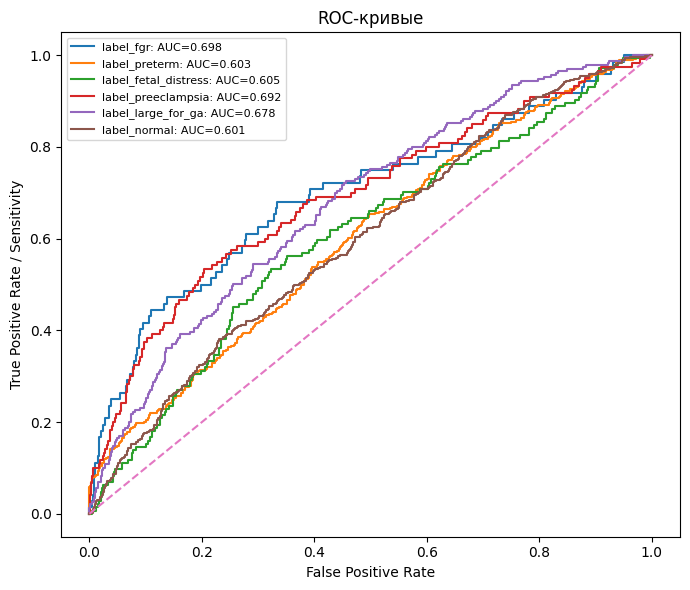


Precision-Recall Curves for AutoGluon (Default config):


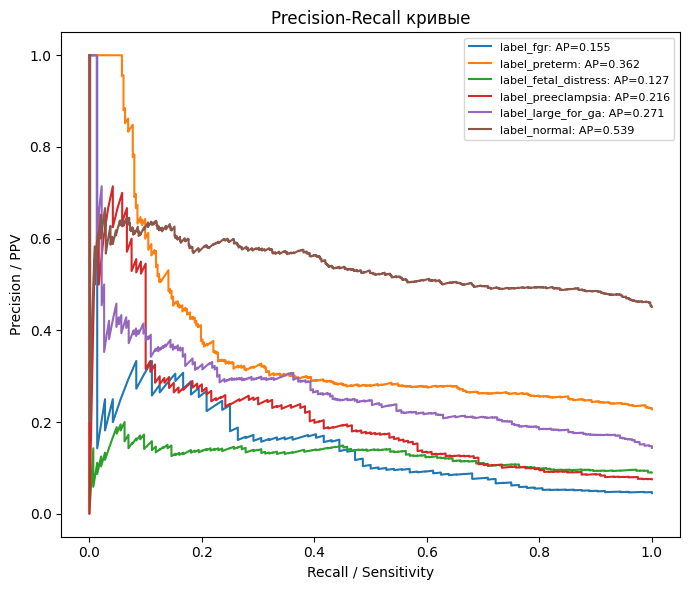

In [ ]:
ag_default_result = results_ag_early['boosting_trees']

display_metrics(
    per_label_metrics=ag_default_result["per_label_metrics"],
    global_metrics=ag_default_result["global_metrics"],
)

print("\nROC AUC Curves for AutoGluon (Default config):")
plot_roc_curves(ag_default_result["y_test"], ag_default_result["test_proba"])

print("\nPrecision-Recall Curves for AutoGluon (Default config):")
plot_pr_curves(ag_default_result["y_test"], ag_default_result["test_proba"])

### Save AutoGluon Model

In [ ]:
ag_artifact_path = ARTIFACTS_DIR / f"{results_ag_early['boosting_trees']['experiment_name']}.joblib"
save_autogluon_artifact(
    result=results_ag_early['boosting_trees'],
    save_path=ag_artifact_path,
)

Saved AutoGluon artifact metadata: drive/MyDrive/colab/internship/artifacts/autogluon_early_w14_boosting_trees.joblib


# Инференс и SHAP

In [47]:
X, y = load_xy(X_EARLY_PATH, Y_PATH, LABEL_COLUMNS)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nLabel distribution")
display(y.mean().sort_values(ascending=False).to_frame('positive_rate'))

X shape: (7966, 98)
y shape: (7966, 6)

Label distribution


,positive_rate
label_normal,0.453176
label_preterm,0.217173
label_large_for_ga,0.138087
label_fetal_distress,0.092769
label_preeclampsia,0.073061
label_fgr,0.048079


In [48]:
def get_transformed_feature_names(preprocessor) -> list[str]:
    return preprocessor.get_feature_names_out().tolist()


def get_top_shap_features_for_sample(
    pipeline,
    X_sample: pd.DataFrame,
    label: str,
    k: int = 3,
) -> list[dict]:
    """
    Возвращает top-k SHAP признаков для одной метки и одного пациента.
    """

    preprocessor = pipeline.named_steps["preprocess"]
    multilabel_model = pipeline.named_steps["model"]

    if label not in multilabel_model.models_:
        return []

    model = multilabel_model.models_[label]

    X_transformed = preprocessor.transform(X_sample)
    feature_names = get_transformed_feature_names(preprocessor)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_transformed)

    values = shap_values.values[0]

    # Для некоторых моделей SHAP может вернуть 2D для классов
    if values.ndim > 1:
        values = values[:, -1]

    top_idx = np.argsort(np.abs(values))[::-1][:k]

    result = []
    for idx in top_idx:
        result.append({
            "feature": feature_names[idx],
            "shap_value": float(values[idx]),
            "impact": "increase_risk" if values[idx] > 0 else "decrease_risk",
            "abs_shap_value": float(abs(values[idx])),
        })

    return result


def get_top_shap_features_by_label(
    pipeline,
    X_sample: pd.DataFrame,
    labels: list[str] | None = None,
    k: int = 3,
) -> list[dict]:
    """
    Возвращает список:
    [
        {
            "label": "...",
            "top_features": [...]
        }
    ]
    """

    multilabel_model = pipeline.named_steps["model"]

    if labels is None:
        labels = list(multilabel_model.models_.keys())

    explanations = []

    for label in labels:
        explanations.append({
            "label": label,
            "top_features": get_top_shap_features_for_sample(
                pipeline=pipeline,
                X_sample=X_sample,
                label=label,
                k=k,
            )
        })

    return explanations


def predict_with_shap_explanations(
    pipeline,
    X_patient: pd.DataFrame,
    thresholds: dict[str, float] | None = None,
    k: int = 3,
    include_normal: bool = True,
) -> list[dict]:
    """
    Инференс для одного пациента.

    Возвращает:
    [
        {
            "label": "label_preeclampsia",
            "probability": 0.34,
            "threshold": 0.21,
            "prediction": 1,
            "top_features": [...]
        }
    ]
    """

    if len(X_patient) != 1:
        raise ValueError("X_patient должен содержать ровно одну строку.")

    proba = pipeline.predict_proba(X_patient)

    thresholds = thresholds or {
        label: 0.5 for label in proba.columns
    }

    results = []

    train_labels = list(proba.columns)

    shap_by_label = {
        item["label"]: item["top_features"]
        for item in get_top_shap_features_by_label(
            pipeline=pipeline,
            X_sample=X_patient,
            labels=train_labels,
            k=k,
        )
    }

    for label in train_labels:
        probability = float(proba.loc[0, label])
        threshold = float(thresholds.get(label, 0.5))

        results.append({
            "label": label,
            "probability": probability,
            "probability_percent": round(probability * 100, 2),
            "threshold": threshold,
            "prediction": int(probability >= threshold),
            "top_features": shap_by_label.get(label, []),
        })

    if include_normal:
        complication_probs = [
            float(proba.loc[0, label])
            for label in train_labels
            if label != "label_normal"
        ]

        normal_probability = float(np.prod([1 - p for p in complication_probs]))

        results.append({
            "label": "label_normal",
            "probability": normal_probability,
            "probability_percent": round(normal_probability * 100, 2),
            "threshold": 0.5,
            "prediction": int(
                all(r["prediction"] == 0 for r in results)
            ),
            "top_features": [],
        })

    return results

In [49]:
model_path = ARTIFACTS_DIR / 'catboost_early_14w.joblib'

if os.path.exists(model_path):
    print('Loading existing model...')
    pipeline, thresholds, label_columns, complication_columns = load_trained_model(model_path)
else:
    result = train_experiment(
        model_name='catboost',
        experiment_name='catboost',
        x_path=X_EARLY_PATH,
        y_path=Y_PATH,
        label_columns=LABEL_COLUMNS,
        model_params={},
        threshold_strategy='f1',
        derive_normal_from_complications=True,
        random_state=42,
        show_plots=False,
    )
    save_trained_model(result, X, model_path)
    display_metrics(result['per_label_metrics'], result['global_metrics'])
    pipeline = result['pipeline']
    thresholds = result['thresholds']

Experiment: catboost
Model: catboost
Train: (5097, 98), Valid: (1275, 98), Test: (1594, 98)
Train labels: ['label_fgr', 'label_preterm', 'label_fetal_distress', 'label_preeclampsia', 'label_large_for_ga']
Saved model artifact: drive/MyDrive/colab/internship/artifacts/catboost_early_14w.joblib

Per-label metrics:


,label,prevalence,roc_auc,pr_auc,recall_sensitivity,specificity,precision,f1,threshold
0,label_fgr,0.045169,0.641271,0.111342,0.222222,0.890933,0.087912,0.125984,0.316794
1,label_preterm,0.227729,0.589104,0.356792,0.771350,0.324939,0.252025,0.379919,0.327579
2,label_fetal_distress,0.090339,0.607150,0.135512,0.444444,0.722759,0.137339,0.209836,0.360754
3,label_preeclampsia,0.075282,0.696263,0.186210,0.375000,0.870421,0.190678,0.252809,0.374067
4,label_large_for_ga,0.143664,0.671849,0.259580,0.768559,0.453480,0.190889,0.305821,0.286916
5,label_normal,0.451694,0.590713,0.533770,0.106944,0.937071,0.583333,0.180751,NaN



Global metrics:


,value
subset_accuracy_exact_match,0.111041
hamming_loss,0.353513
jaccard_samples,0.218632
precision_micro,0.215808
recall_micro,0.399272
f1_micro,0.280179
precision_macro,0.240363
recall_macro,0.448087
f1_macro,0.242520


In [50]:
X_patient = X.iloc[[0]].copy()

prediction = predict_with_shap_explanations(
    pipeline=pipeline,
    X_patient=X_patient,
    thresholds=thresholds,
    k=10,
)

prediction

[{'label': 'label_fgr',
  'probability': 0.8219878897585611,
  'probability_percent': 82.2,
  'threshold': 0.3167941591825424,
  'prediction': 1,
  'top_features': [{'feature': 'num__fbhcg',
    'shap_value': 0.46355498855485194,
    'impact': 'increase_risk',
    'abs_shap_value': 0.46355498855485194},
   {'feature': 'num__screening_preterm_risk',
    'shap_value': -0.26973146262501585,
    'impact': 'decrease_risk',
    'abs_shap_value': 0.26973146262501585},
   {'feature': 'num__fbhcg_mom',
    'shap_value': 0.22655916568814496,
    'impact': 'increase_risk',
    'abs_shap_value': 0.22655916568814496},
   {'feature': 'num__gestational_age_ctr',
    'shap_value': 0.20678871602831395,
    'impact': 'increase_risk',
    'abs_shap_value': 0.20678871602831395},
   {'feature': 'num__interbirth_interval_raw',
    'shap_value': -0.17301464093630795,
    'impact': 'decrease_risk',
    'abs_shap_value': 0.17301464093630795},
   {'feature': 'num__pappa_mom',
    'shap_value': -0.15256367997068

In [51]:
for pred in prediction:
    print(f'Label: {pred['label']}')
    print('Top features:', [f['feature'] for f in pred['top_features']])
    print()

Label: label_fgr
Top features: ['num__fbhcg', 'num__screening_preterm_risk', 'num__fbhcg_mom', 'num__gestational_age_ctr', 'num__interbirth_interval_raw', 'num__pappa_mom', 'num__text_has_myoma', 'num__crl', 'num__ua_right_pi', 'num__us_date_year']

Label: label_preterm
Top features: ['num__fbhcg_mom', 'num__interbirth_interval_raw', 'num__text_has_anemia', 'num__screening_fgr_risk', 'num__last_menstruation_date_month', 'num__uapi_mean', 'num__fhr', 'num__screening_days', 'num__pregnancy_number_raw', 'num__is_multiple_pregnancy']

Label: label_fetal_distress
Top features: ['num__interbirth_interval_raw', 'num__last_menstruation_date_year', 'num__fbhcg_mom', 'num__plgf', 'num__text_has_myoma', 'num__pappa_mom', 'num__weight_final', 'num__weight_start_pregnancy', 'num__dvpi', 'num__parity']

Label: label_preeclampsia
Top features: ['num__weight_prisca', 'num__fbhcg_mom', 'num__interbirth_interval_raw', 'num__screening_fgr_risk', 'num__text_has_hypertension', 'num__us_date_year', 'num__sc

# Подготовка к OCR приложению

In [52]:
OCR_TO_X_EARLY_FEATURE_MAP = {
    # демография / антропометрия
    "age": "age_final",
    "height": "height_final",
    "weight": "weight_final",
    "bmi": "bmi_final",

    # срок скрининга
    "gestational_age_decimal": "screening_ga_weeks",
    "gestational_weeks": "screening_weeks",
    "gestational_days": "screening_days",

    # УЗИ 11–13 недель
    "crl": "crl",
    "nt": "nt",
    "fhr": "fhr",
    "ua_left_pi": "ua_left_pi",
    "ua_right_pi": "ua_right_pi",
    "uapi_mean": "uapi_mean",
    "nasal_bone": "nasal_bone",

    # биохимия
    "pappa": "pappa",
    "pappa_mom": "pappa_mom",
    "fbhcg": "fbhcg",
    "fbhcg_mom": "fbhcg_mom",
}

OPTIONAL_SCREENING_FEATURES = [
    "uapi_mom",
    "dvpi",
    "tricuspid_regurgitation",
    "screening_pe_34_risk",
    "screening_pe_37_risk",
    "screening_pe_42_risk",
    "screening_pe_risk",
    "screening_fgr_risk",
    "screening_preterm_risk",
    "risk_21",
    "risk_18",
    "risk_13",
    "base21",
    "base18",
    "base13",
]

In [53]:
def build_screening_ocr_dataset_from_x_early(
    x_early_path: str | Path = X_EARLY_PATH,
    y_path: str | Path = Y_PATH,
    out_x_path: str | Path = SCREENING_OCR_X_PATH,
    feature_report_path: str | Path = SCREENING_OCR_FEATURE_REPORT_PATH,
    min_completeness: float = 0.05,
    include_optional_screening_features: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Формирует X для обучения модели, совместимой с OCR-приложением.

    Главное отличие от полного X_early_w14:
    - оставляем только признаки, которые можно получить из PDF скрининга;
    - не добавляем анамнез, текстовые флаги и другие поля, которых нет в OCR JSON;
    - сохраняем порядок колонок для последующего инференса.
    """
    x_early_path = Path(x_early_path)
    y_path = Path(y_path)
    out_x_path = Path(out_x_path)
    feature_report_path = Path(feature_report_path)

    X_early = pd.read_csv(x_early_path, encoding="utf-8-sig")
    print(X_early.info())
    y = pd.read_csv(y_path, encoding="utf-8-sig")

    base_cols = [
        x_col
        for x_col in OCR_TO_X_EARLY_FEATURE_MAP.values()
        if x_col in X_early.columns
    ]

    optional_cols = []
    if include_optional_screening_features:
        optional_cols = [
            col
            for col in OPTIONAL_SCREENING_FEATURES
            if col in X_early.columns
        ]

    selected_cols = list(dict.fromkeys(base_cols + optional_cols))
    X_screening = X_early[selected_cols].copy()

    # Отчёт по выбранным признакам
    report = pd.DataFrame({
        "feature": X_screening.columns,
        "dtype": [str(X_screening[c].dtype) for c in X_screening.columns],
        "non_null_count": [X_screening[c].notna().sum() for c in X_screening.columns],
        "missing_count": [X_screening[c].isna().sum() for c in X_screening.columns],
        "completeness": [X_screening[c].notna().mean() for c in X_screening.columns],
        "n_unique": [X_screening[c].nunique(dropna=True) for c in X_screening.columns],
    })

    # Удаляем совсем бесполезные признаки: почти пустые или константные.
    drop_cols = report.loc[
        (report["completeness"] < min_completeness)
        | (report["n_unique"] <= 1),
        "feature"
    ].tolist()

    X_screening = X_screening.drop(columns=drop_cols, errors="ignore")

    report["drop_reason"] = ""
    report.loc[report["completeness"] < min_completeness, "drop_reason"] += "low_completeness;"
    report.loc[report["n_unique"] <= 1, "drop_reason"] += "constant;"
    report["used_in_model"] = ~report["feature"].isin(drop_cols)

    out_x_path.parent.mkdir(parents=True, exist_ok=True)
    feature_report_path.parent.mkdir(parents=True, exist_ok=True)

    X_screening.to_csv(out_x_path, index=False, encoding="utf-8-sig")
    report.to_csv(feature_report_path, index=False, encoding="utf-8-sig")

    print(f"X_early shape:      {X_early.shape}")
    print(f"X_screening shape:  {X_screening.shape}")
    print(f"y shape:            {y.shape}")
    print(f"Saved X_screening:  {out_x_path}")
    print(f"Saved report:       {feature_report_path}")

    print("\nИспользуемые признаки:")
    display(report[report["used_in_model"]].sort_values("completeness", ascending=False))

    print("\nУдалённые признаки:")
    display(report[~report["used_in_model"]].sort_values("completeness"))

    return X_screening, y, report

In [54]:
X_screening_ocr, y_screening, screening_report = build_screening_ocr_dataset_from_x_early(
    x_early_path=X_EARLY_PATH,
    y_path=Y_PATH,
    min_completeness=0.05,
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7966 entries, 0 to 7965
Data columns (total 98 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age_at_us_11_13                    7966 non-null   float64
 1   height_start_pregnancy             7946 non-null   float64
 2   weight_start_pregnancy             7946 non-null   float64
 3   bmi_start_pregnancy                7946 non-null   float64
 4   child_order_raw                    7966 non-null   float64
 5   fetuses_count_delivery_protocol    7965 non-null   float64
 6   НачалоПоловойЖизниС                6275 non-null   float64
 7   pregnancy_number_raw               7945 non-null   float64
 8   interbirth_interval_raw            7951 non-null   float64
 9   initial_weight                     5957 non-null   float64
 10  kids                               7966 non-null   float64
 11  screening_weeks                    7966 non-null   float

,feature,dtype,non_null_count,missing_count,completeness,n_unique,drop_reason,used_in_model
0,age_final,float64,7966,0,1.000000,39,,True
1,height_final,float64,7966,0,1.000000,58,,True
2,weight_final,float64,7966,0,1.000000,399,,True
4,screening_ga_weeks,float64,7966,0,1.000000,34,,True
5,screening_weeks,float64,7966,0,1.000000,8,,True
6,screening_days,float64,7966,0,1.000000,7,,True
14,pappa,float64,7966,0,1.000000,5042,,True
16,fbhcg,float64,7966,0,1.000000,4851,,True
7,crl,float64,7960,6,0.999247,377,,True
3,bmi_final,float64,7946,20,0.997489,64,,True



Удалённые признаки:


,feature,dtype,non_null_count,missing_count,completeness,n_unique,drop_reason,used_in_model


Experiment: xgboost_screening_ocr_w14
Model: xgboost
Train: (5097, 98), Valid: (1275, 98), Test: (1594, 98)
Train labels: ['label_fgr', 'label_preterm', 'label_fetal_distress', 'label_preeclampsia', 'label_large_for_ga']


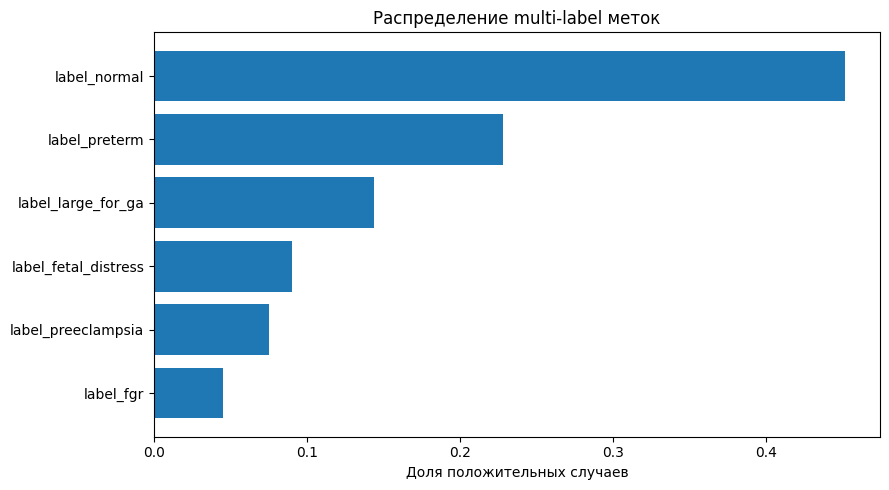

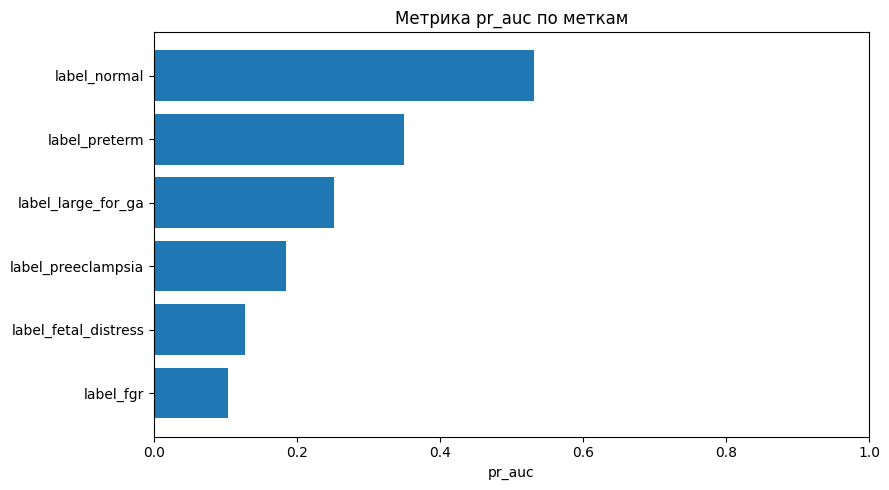

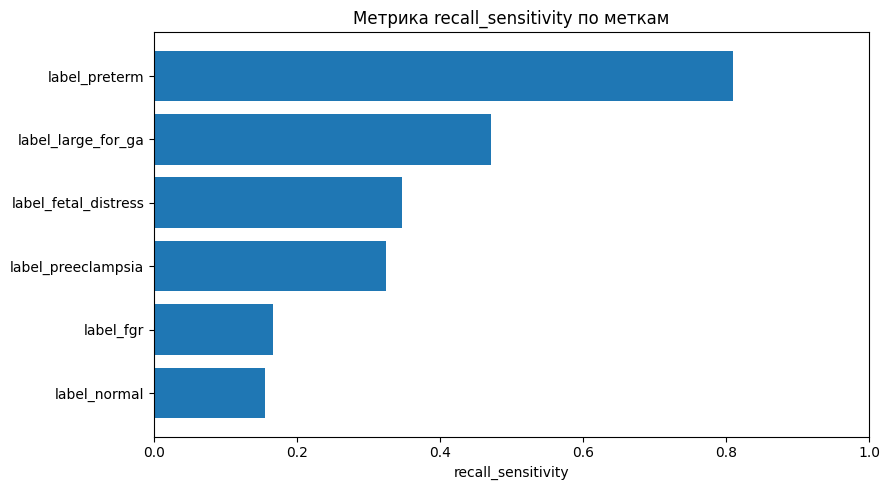

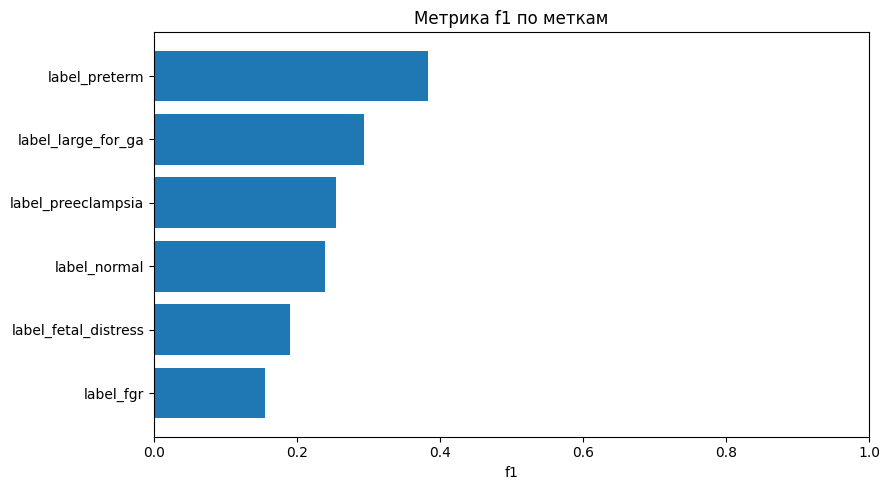

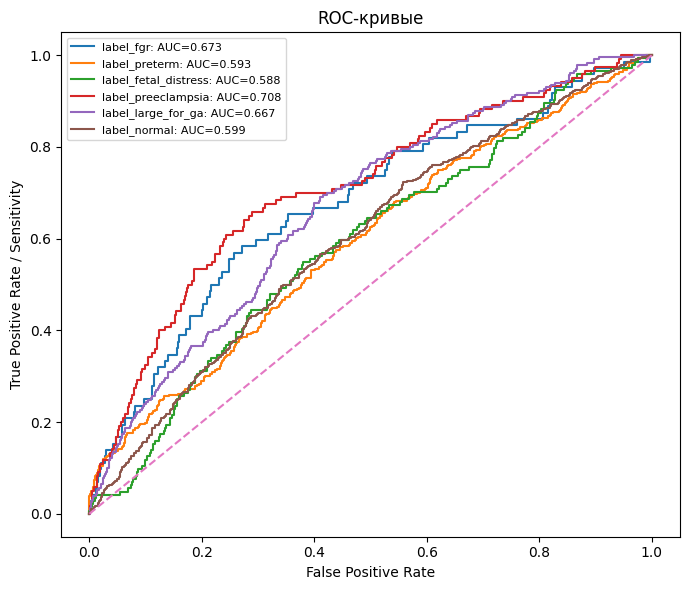

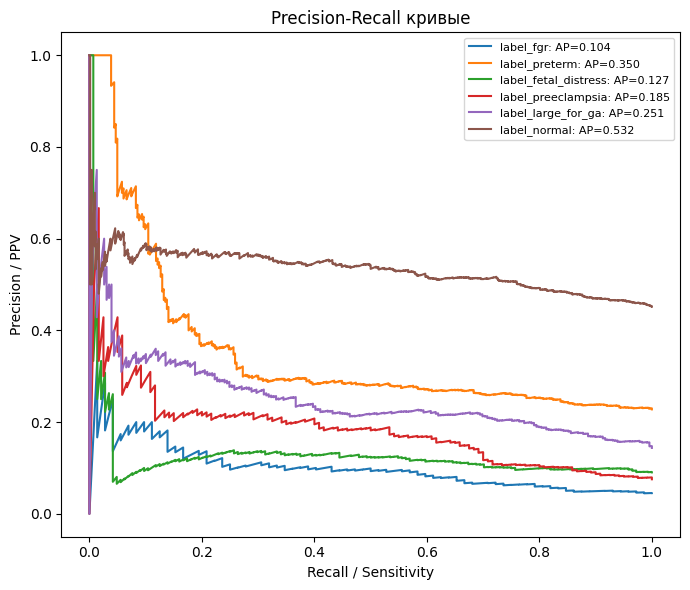

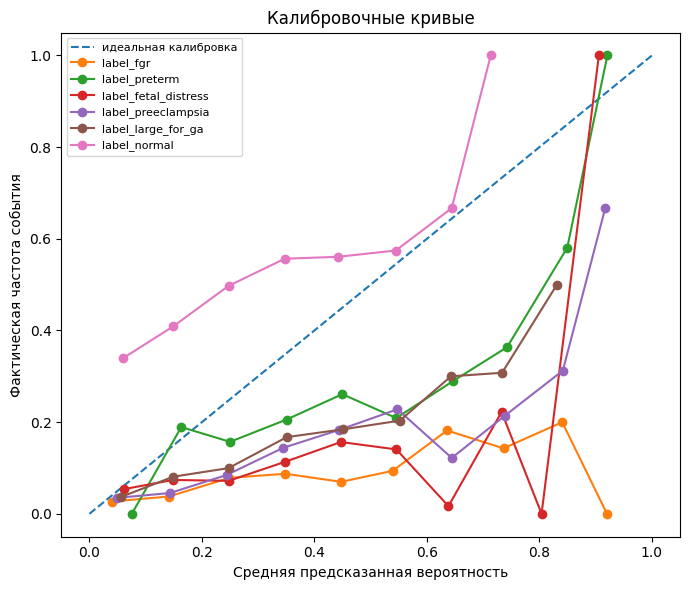

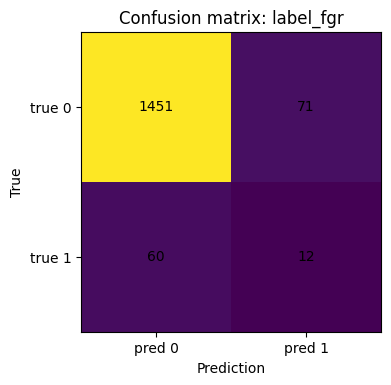

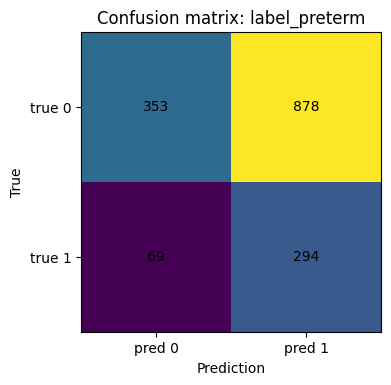

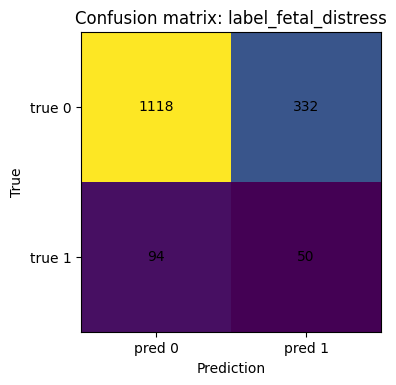

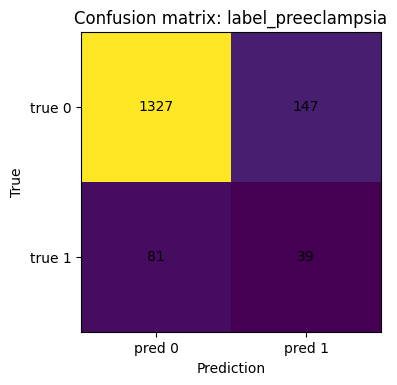

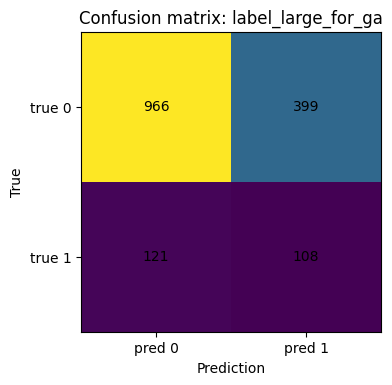

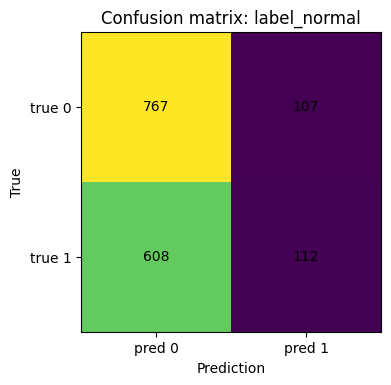


Per-label metrics:


,label,prevalence,roc_auc,pr_auc,recall_sensitivity,specificity,precision,f1,threshold
0,label_fgr,0.045169,0.673410,0.104002,0.166667,0.953351,0.144578,0.154839,0.497267
1,label_preterm,0.227729,0.593012,0.350163,0.809917,0.286759,0.250853,0.383062,0.296494
2,label_fetal_distress,0.090339,0.588367,0.127267,0.347222,0.771034,0.130890,0.190114,0.394103
3,label_preeclampsia,0.075282,0.708424,0.185287,0.325000,0.900271,0.209677,0.254902,0.436323
4,label_large_for_ga,0.143664,0.667409,0.251318,0.471616,0.707692,0.213018,0.293478,0.426672
5,label_normal,0.451694,0.599027,0.531725,0.155556,0.877574,0.511416,0.238552,NaN



Global metrics:


,value
subset_accuracy_exact_match,0.148055
hamming_loss,0.310226
jaccard_samples,0.238237
precision_micro,0.241271
recall_micro,0.373180
f1_micro,0.293066
precision_macro,0.243405
recall_macro,0.379330
f1_macro,0.252491


In [55]:
result_screening = train_experiment(
    model_name="xgboost",
    experiment_name="xgboost_screening_ocr_w14",
    x_path=X_EARLY_PATH,
    y_path=Y_PATH,
    threshold_strategy="f1",
    derive_normal_from_complications=True,
    save_artifacts=True,
    show_plots=True,
)

display_metrics(
    per_label_metrics=result_screening["per_label_metrics"],
    global_metrics=result_screening["global_metrics"],
)

In [56]:
save_trained_model(
    result=result_screening,
    feature_df=X,
    save_path=SCREENING_OCR_MODEL_PATH,
)

Saved model artifact: drive/MyDrive/colab/internship/artifacts/screening_ocr.joblib
